# Module 09 — Biological Interpretation (v5)

This notebook visualizes pre-computed pathway enrichment, transcription factor
activity, and pain gene analyses from `scripts/09_interpretation.py`. These
results build on the DE genes from Module 08 to provide biological context.

**Pipeline version:** v5 (CCA-based, 12 modules)

**Data sources:**
- `results/interpretation/pathway_enrichment/` — ORA dot plots and GSEA results
- `results/interpretation/tf_activity/` — TF activity heatmap and results
- `results/interpretation/pain_genes.tsv` — Pain gene DE results
- `results/interpretation/pain_genes_heatmap.png` — Pain gene visualization

In [1]:
import warnings
warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=UserWarning)

from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Image, display, Markdown

plt.rcParams.update({'figure.dpi': 120, 'savefig.dpi': 200, 'savefig.bbox': 'tight'})

# ── Paths ──────────────────────────────────────────────────────────────────
BASE = Path('..').resolve()
RESULTS = BASE / 'results' / 'interpretation'
PATHWAY_DIR = RESULTS / 'pathway_enrichment'
TF_DIR = RESULTS / 'tf_activity'

print(f'Results directory: {RESULTS}')
print(f'Pathway plots:    {len(list(PATHWAY_DIR.glob("*.png")))} files')
print(f'TF files:         {len(list(TF_DIR.glob("*")))} files')

Results directory: /home/ubuntu/lotz-ivd/results/interpretation
Pathway plots:    7 files
TF files:         2 files


## Over-Representation Analysis (ORA)

ORA tests whether DE gene lists are enriched for known biological pathways
(GO, KEGG, Reactome). Separate analyses for up- and down-regulated genes in
each cell type.

### Summary Statistics

In [2]:
# Load all enrichment results
enrich_path = PATHWAY_DIR / 'all_enrichment_results.tsv'
if enrich_path.exists():
    enrich = pd.read_csv(enrich_path, sep='\t')
    print(f'Total enrichment results: {len(enrich)}')
    
    # Show summary by cell type and direction
    if 'cell_type' in enrich.columns and 'direction' in enrich.columns:
        summary = enrich.groupby(['cell_type', 'direction']).size().reset_index(name='n_terms')
        display(summary.style.set_caption('ORA Enrichment Terms by Cell Type and Direction'))
    elif 'source' in enrich.columns:
        summary = enrich.groupby('source').size().reset_index(name='n_terms')
        display(summary)
    
    # Show top terms — check multiple possible column names for p-value
    p_col = next((c for c in ['Adjusted P-value', 'p_value', 'pvalue', 'padj', 'P-value']
                  if c in enrich.columns), None)
    if p_col:
        top = enrich.nsmallest(20, p_col)
        cols = [c for c in ['cell_type', 'direction', 'Term', 'name', 'source',
                            'library', p_col] if c in top.columns]
        display(top[cols].style.set_caption('Top 20 Most Significant ORA Terms'))
    else:
        print(f'  (No recognized p-value column found; columns: {list(enrich.columns)})')
else:
    print('Enrichment results file not found')

Total enrichment results: 11407


,cell_type,direction,n_terms
0,AF_outer,down,899
1,AF_outer,up,339
2,NP_fibrocartilaginous,down,4636
3,NP_fibrocartilaginous,up,4875
4,NP_mature_chondrocyte,down,160
5,NP_mature_chondrocyte,up,498


,cell_type,direction,Term,library,Adjusted P-value
10024,NP_fibrocartilaginous,down,Cell Cycle R-HSA-1640170,Reactome_2022,0.000000
10025,NP_fibrocartilaginous,down,"Cell Cycle, Mitotic R-HSA-69278",Reactome_2022,0.000000
6290,NP_fibrocartilaginous,down,Cell Cycle R-HSA-1640170,Reactome_2022,0.000000
6965,NP_fibrocartilaginous,down,E2F Targets,MSigDB_Hallmark_2020,0.000000
10710,NP_fibrocartilaginous,down,E2F Targets,MSigDB_Hallmark_2020,0.000000
6291,NP_fibrocartilaginous,down,"Cell Cycle, Mitotic R-HSA-69278",Reactome_2022,0.000000
10711,NP_fibrocartilaginous,down,G2-M Checkpoint,MSigDB_Hallmark_2020,0.000000
6966,NP_fibrocartilaginous,down,G2-M Checkpoint,MSigDB_Hallmark_2020,0.000000
10026,NP_fibrocartilaginous,down,Cell Cycle Checkpoints R-HSA-69620,Reactome_2022,0.000000
6292,NP_fibrocartilaginous,down,Cell Cycle Checkpoints R-HSA-69620,Reactome_2022,0.000000


### ORA Dot Plots — Upregulated Genes

Upregulated enrichment plots: 3


**AF outer (UP)**

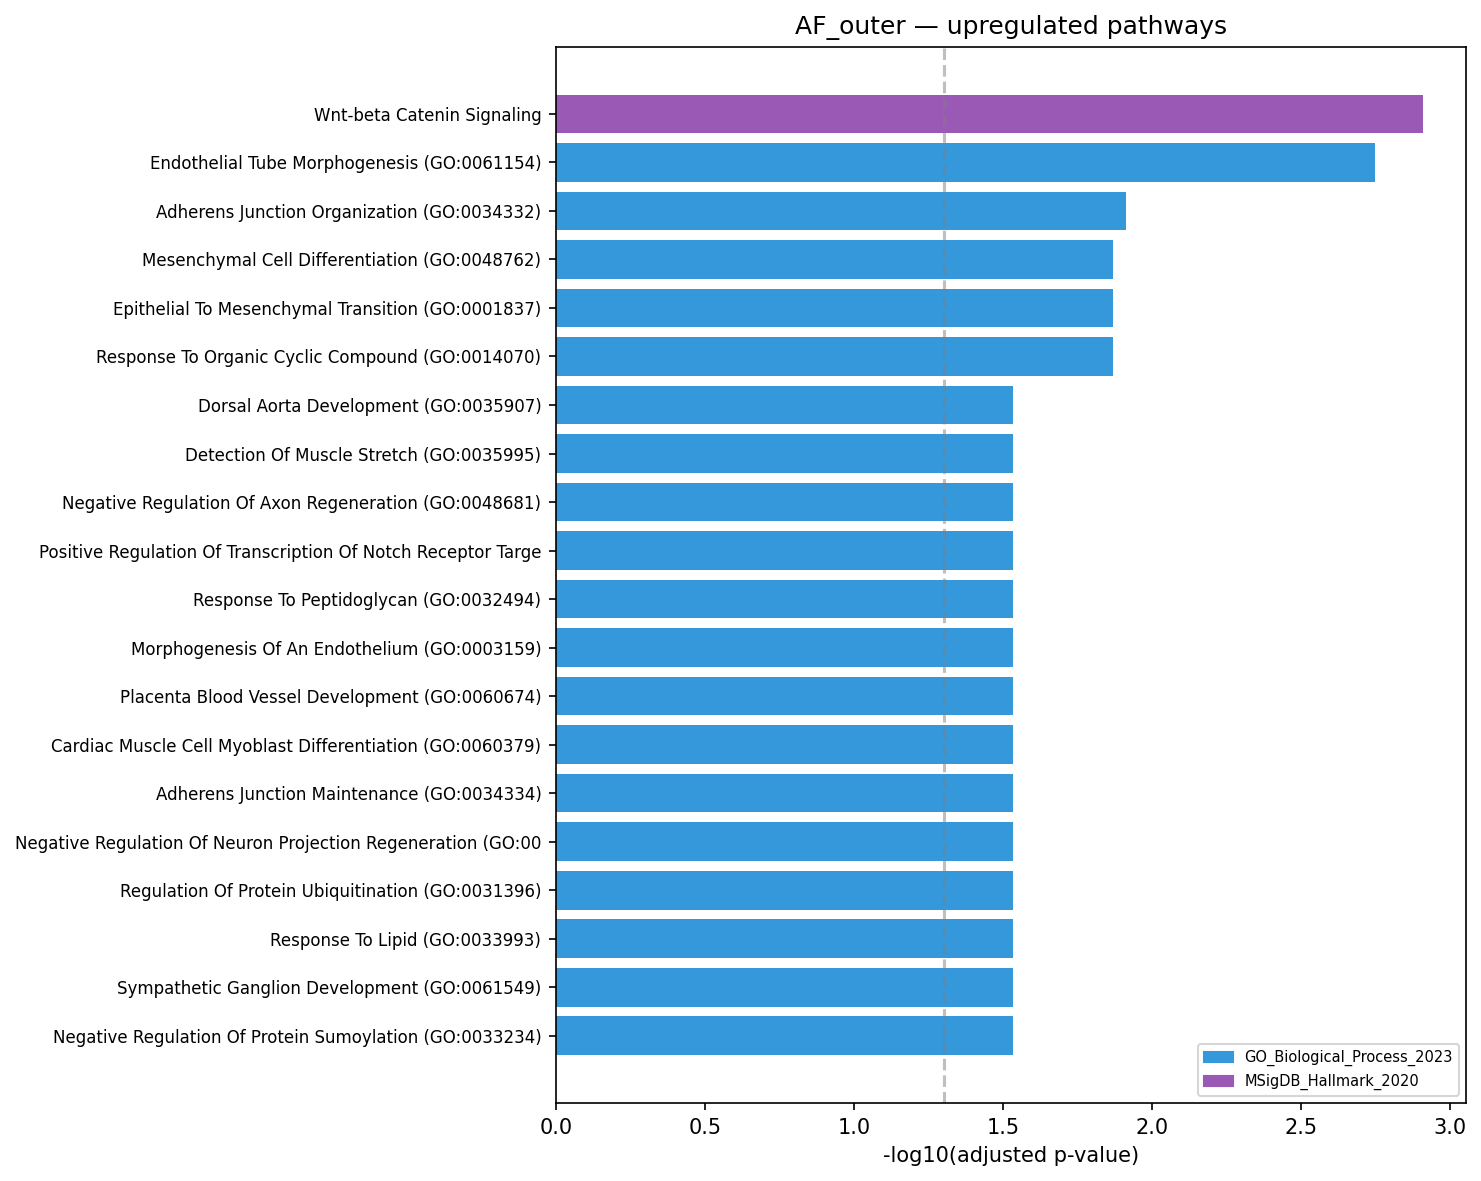

**NP fibrocartilaginous (UP)**

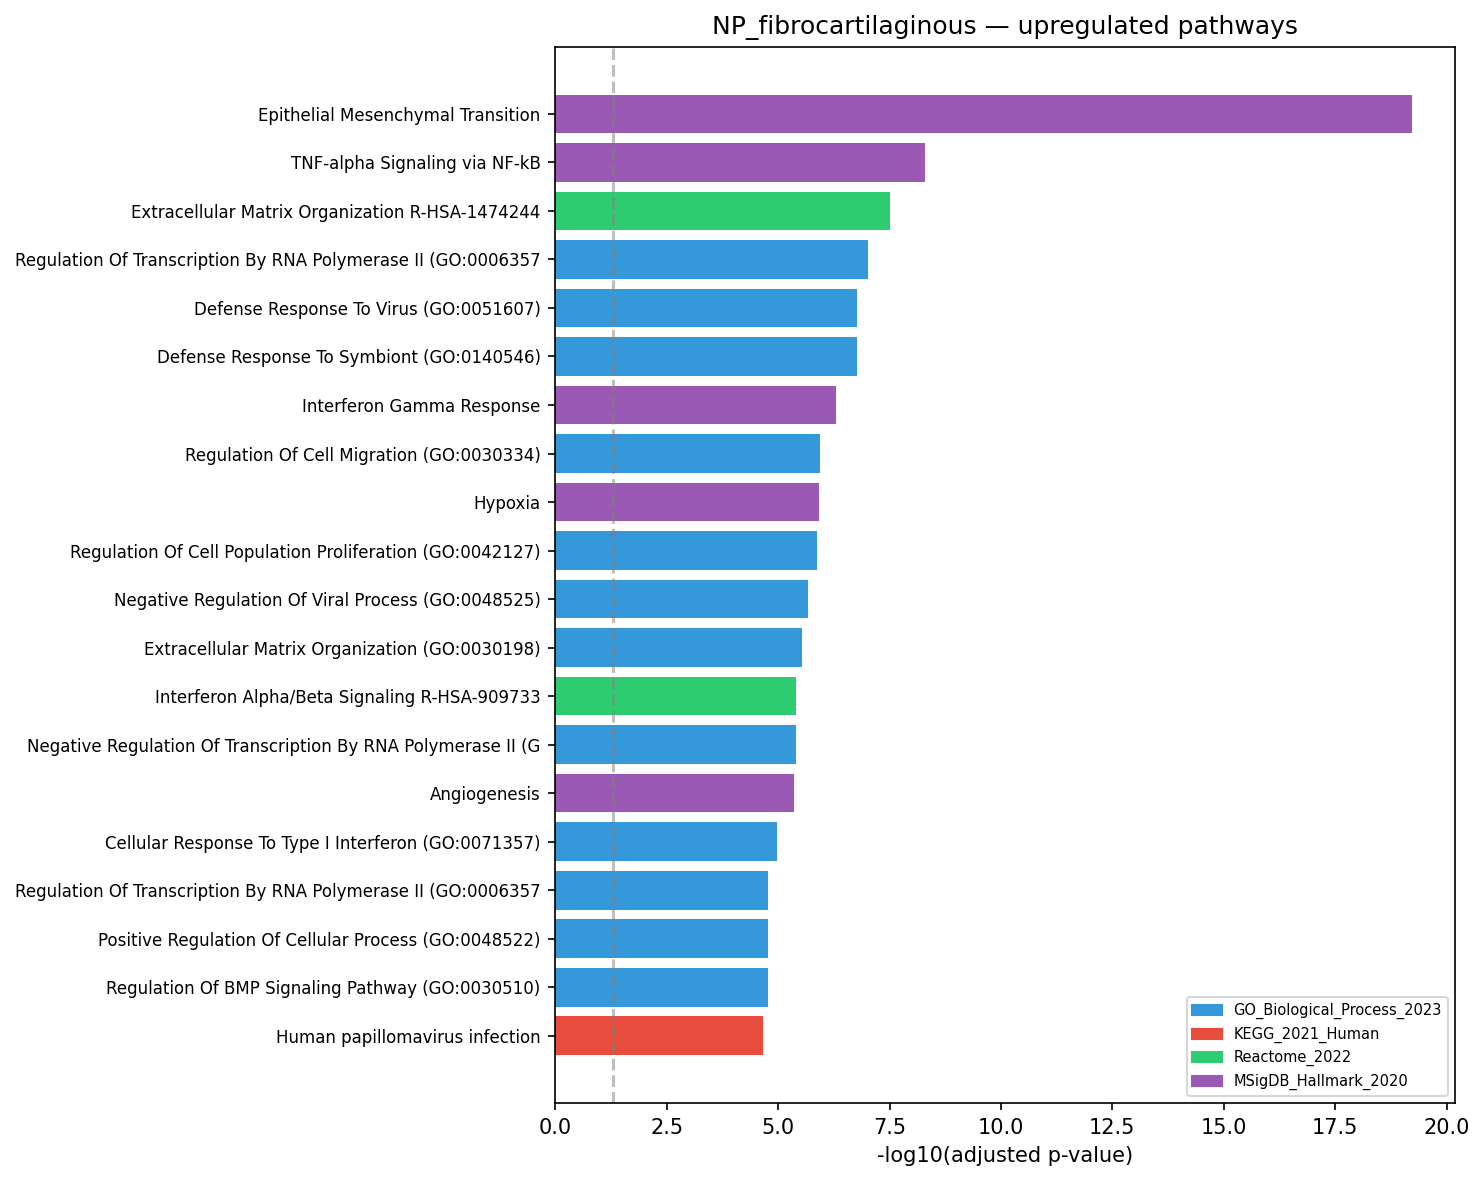

**NP mature chondrocyte (UP)**

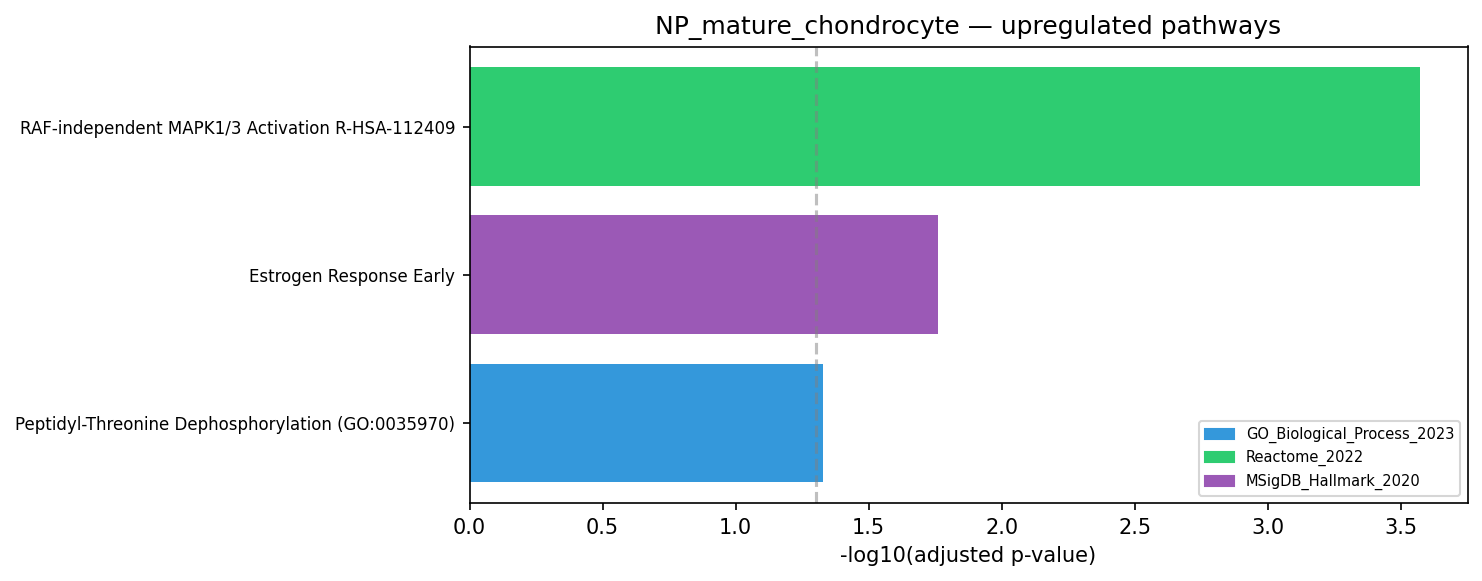

In [3]:
# Display ORA plots for upregulated genes
up_plots = sorted(PATHWAY_DIR.glob('enrichment_*_up.png'))
print(f'Upregulated enrichment plots: {len(up_plots)}')

for fpath in up_plots:
    label = fpath.stem.replace('enrichment_', '').replace('_up', ' (UP)').replace('_', ' ')
    display(Markdown(f'**{label}**'))
    display(Image(filename=str(fpath), width=800))

### ORA Dot Plots — Downregulated Genes

Downregulated enrichment plots: 3


**AF outer (DOWN)**

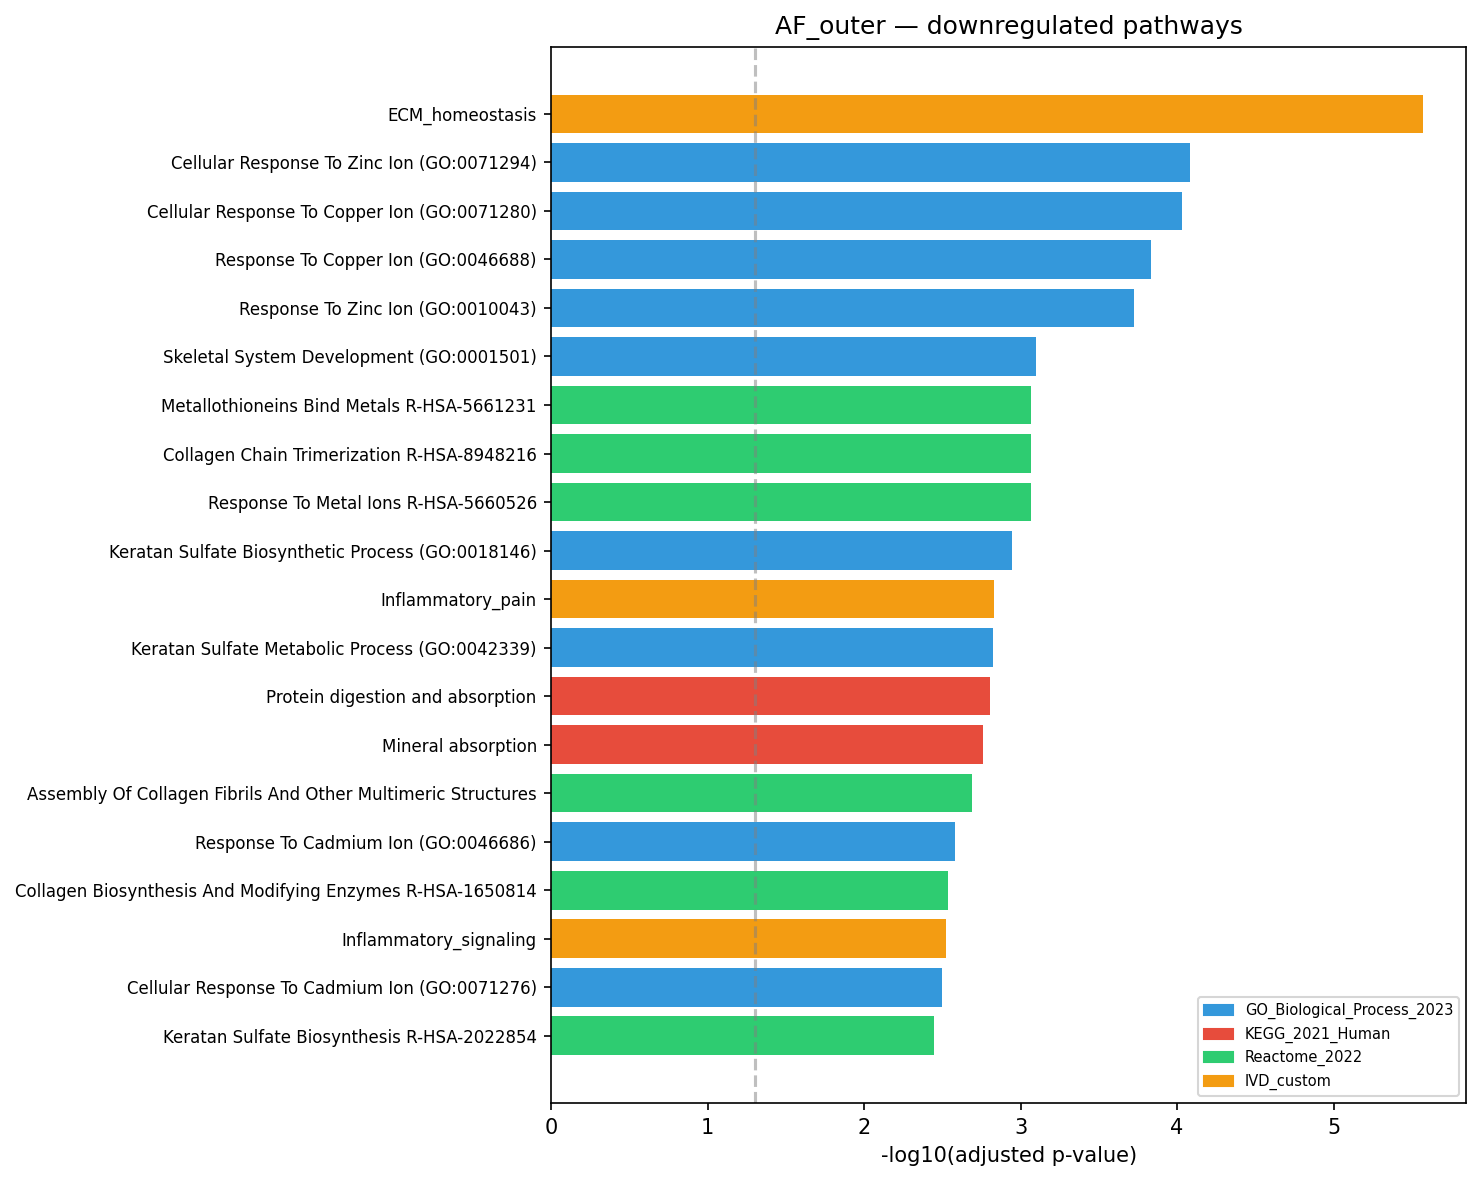

**NP fibrocartilaginous (DOWN)**

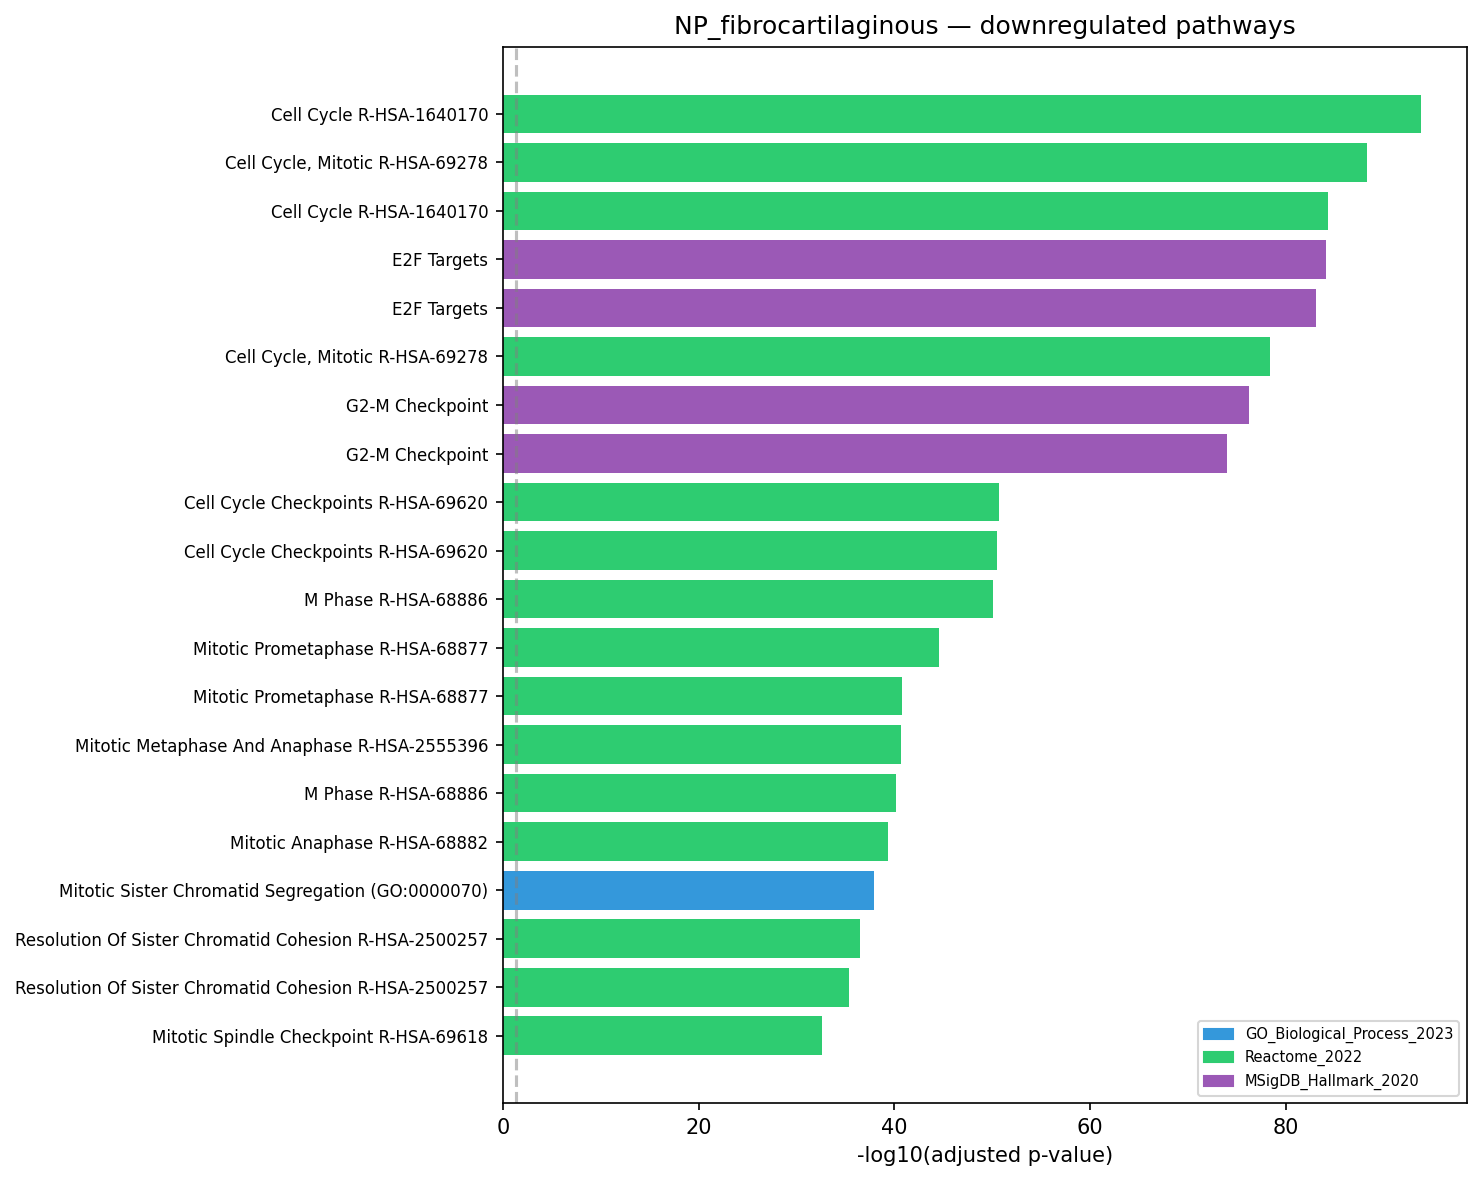

**NP mature chondrocyte (DOWN)**

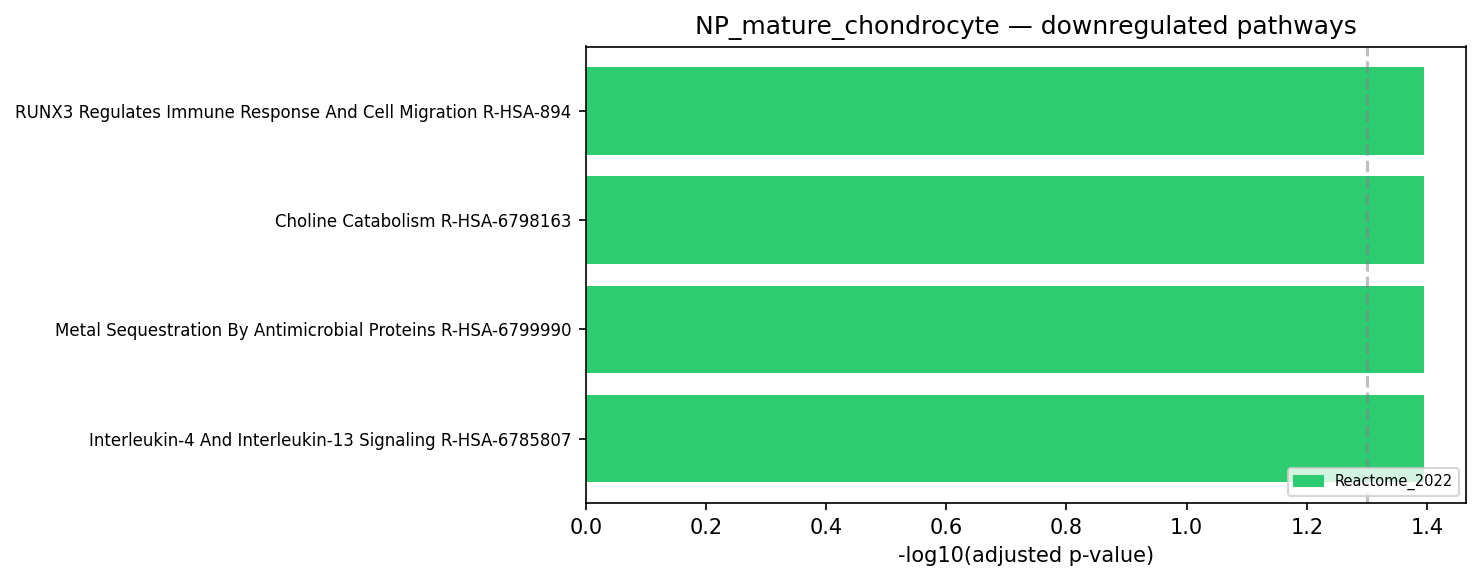

In [4]:
# Display ORA plots for downregulated genes
down_plots = sorted(PATHWAY_DIR.glob('enrichment_*_down.png'))
print(f'Downregulated enrichment plots: {len(down_plots)}')

for fpath in down_plots:
    label = fpath.stem.replace('enrichment_', '').replace('_down', ' (DOWN)').replace('_', ' ')
    display(Markdown(f'**{label}**'))
    display(Image(filename=str(fpath), width=800))

## Gene Set Enrichment Analysis (GSEA)

GSEA uses IVD-specific custom gene sets to assess pathway-level changes without
requiring a significance cutoff on individual genes. The heatmap shows
normalized enrichment scores (NES) across cell types.

In [5]:
# GSEA results summary
gsea_path = PATHWAY_DIR / 'gsea_results.tsv'
if gsea_path.exists():
    gsea = pd.read_csv(gsea_path, sep='\t')
    print(f'Total GSEA terms tested: {len(gsea)}')
    
    # Check multiple possible column names for significance
    fdr_col = next((c for c in ['FDR q-val', 'padj', 'pval', 'NOM p-val', 'fdr']
                    if c in gsea.columns), None)
    if fdr_col:
        sig_gsea = gsea[gsea[fdr_col] < 0.05]
        print(f'Significant GSEA terms ({fdr_col} < 0.05): {len(sig_gsea)}')
    else:
        print(f'  (No recognized FDR/p-value column found; columns: {list(gsea.columns)})')
    
    # Show top terms
    display(gsea.head(20).style.set_caption('Top GSEA Results'))
else:
    print('GSEA results file not found')

Total GSEA terms tested: 58837
Significant GSEA terms (FDR q-val < 0.05): 3301


,Name,Term,ES,NES,NOM p-val,FDR q-val,FWER p-val,Tag %,Gene %,Lead_genes,cell_type,comparison,library
0,prerank,Apical Junction Assembly (GO:0043297),-0.691254,-2.029285,0.000000,0.030798,0.023000,19/48,9.51%,CLDN1;MARVELD2;CTNNA1;APC;OCLN;DLG1;MICALL2;ECT2;PARD3;CLDN11;CLDN7;WDR1;PAK2;ARL2;TBCD;RHOA;VCL;SLC39A9;CLDN23,AF_inner,healthy_vs_degenerated_all,GO_Biological_Process_2023
1,prerank,Sulfur Compound Catabolic Process (GO:0044273),-0.826878,-1.996225,0.000000,0.025024,0.037000,13/18,11.66%,GPC1;NUDT8;TST;NAGLU;SUCLG1;GNS;HPSE;NUDT19;NUDT7;SGSH;FITM2;GLB1;IDUA,AF_inner,healthy_vs_degenerated_all,GO_Biological_Process_2023
2,prerank,Bicellular Tight Junction Assembly (GO:0070830),-0.679722,-1.936397,0.000000,0.059458,0.122000,15/41,9.51%,CLDN1;MARVELD2;APC;OCLN;DLG1;MICALL2;ECT2;PARD3;CLDN11;CLDN7;PAK2;ARL2;TBCD;SLC39A9;CLDN23,AF_inner,healthy_vs_degenerated_all,GO_Biological_Process_2023
3,prerank,Membrane Depolarization During Cardiac Muscle Cell Action Potential (GO:0086012),-0.847091,-1.891558,0.002857,0.109719,0.257000,6/15,4.80%,CACNA2D1;ATP1A2;TRPM4;SLC8A1;CACNA1C;SCN2B,AF_inner,healthy_vs_degenerated_all,GO_Biological_Process_2023
4,prerank,mRNA Processing (GO:0006397),0.616280,1.877223,0.000000,0.009622,0.011000,122/205,22.77%,HNRNPH1;ALKBH5;TRA2A;CWF19L2;RNMT;SRSF1;ZRSR2;SF3A1;CWF19L1;MTREX;SF3A2;PLRG1;PRPF3;EIF4A3;PPARGC1A;SNIP1;HNRNPA2B1;ERN1;BUD13;METTL14;SRSF12;SNRPN;U2AF1;PAPOLA;YTHDC1;PPWD1;HNRNPR;SFPQ;PRPF38A;SRSF3;SMU1;HEXIM1;PRPF18;CWC22;HNRNPA1;HNRNPA3;SRSF7;SRSF6;PRPF4B;RNF113A;DDX39B;TRA2B;HNRNPH3;PNN;HNRNPA0;GEMIN2;U2AF2;HNRNPK;DHX15;SNRNP70;SON;HNRNPU;XAB2;RBM22;DDX5;MAGOH;CDC5L;RPRD1B;RBM10;RNPS1;HTATSF1;RBMX;SLU7;DBR1;PRPF40B;NUDT21;CASC3;SF3B1;PRPF4;SYF2;CWC25;SRSF2;BCAS2;HNRNPF;SNRPA1;PPIL3;SRSF8;MBLAC1;SRSF10;GCFC2;RBM5;CRNKL1;LSM8;CELF1;RBM41;RBM4;RBM14;LSM6;PRPF19;SRSF5;SNRPG;NOVA1;SNRPB;PHF5A;PPIH;METTL3;SNRPA;DHX35;DDX39A;RBM4B;RBM8A;FRG1;SNRNP27;CACTIN;SCAF11;NCBP2L;SRSF4;HNRNPC;RNPC3;HNRNPM;ALYREF;FBXO11;MFAP1;DHX38;SNRPD3;SNRPF;SART1;SYNCRIP;CPSF7;PRPF6;CMTR1;WBP4,AF_inner,healthy_vs_degenerated_all,GO_Biological_Process_2023
5,prerank,Cardiac Muscle Cell Action Potential Involved In Contraction (GO:0086002),-0.724856,-1.866649,0.000000,0.136282,0.364000,13/25,16.97%,CACNA2D1;CACNA1C;NEDD4L;SCN2B;KCNH2;GJA1;KCNE1;KCNE4;KCNE3;PKP2;SCN1B;ATP1A1;GJC1,AF_inner,healthy_vs_degenerated_all,GO_Biological_Process_2023
6,prerank,"Regulation Of mRNA Splicing, Via Spliceosome (GO:0048024)",0.669744,1.851776,0.000000,0.013996,0.029000,53/86,19.92%,TRA2A;RBM7;JMJD6;TIA1;WTAP;NUP98;METTL16;SRSF12;YTHDC1;SRSF3;SMU1;CWC22;HNRNPA1;SRSF7;SRSF6;CIRBP;TRA2B;RBM25;HNRNPA0;NSRP1;RBM39;RBM38;CELF6;U2AF2;HNRNPK;SFSWAP;SON;HNRNPU;RBM23;PRMT5;DDX5;MAGOH;RBMXL1;RNPS1;RBMX;WDR77;RBM20;KHDRBS1;HNRNPL;SRSF10;RBM5;QKI;CELF1;RBM15;RBM4;DAZAP1;SAP18;PCBP4;NOVA1;RBM8A;DDX17;RBM24;SRSF4,AF_inner,healthy_vs_degenerated_all,GO_Biological_Process_2023
7,prerank,Monoatomic Anion Transmembrane Transport (GO:0098656),-0.654714,-1.836922,0.000000,0.182865,0.506000,12/42,9.28%,ANO5;LRRC8D;GABRB3;ANO10;SLC5A6;LRRC8E;LRRC8B;SLC12A2;SLC12A7;ANO6;GABRB1;SLC12A6,AF_inner,healthy_vs_degenerated_all,GO_Biological_Process_2023
8,prerank,Positive Regulation Of Transcription From RNA Polymerase II Promoter Involved In Cellular Response To Chemical Stimulus (GO:1901522),0.892781,1.815796,0.000000,0.025075,0.074000,7/13,6.75%,BMP2;VEGFA;DLX5;RELA;XBP1;RBPJ;SMAD9,AF_inner,healthy_vs_degenerated_all,GO_Biological_Process_2023
9,prerank,Regulation Of Fatty Acid Oxidation (GO:0046320),0.861295,1.810918,0.000000,0.021868,0.084000,5/16,2.07%,PDK4;SOX9;ACADL;NR4A3;PPARGC1A,AF_inner,healthy_vs_degenerated_all,GO_Biological_Process_2023


**GSEA Heatmap — IVD Custom Gene Sets**

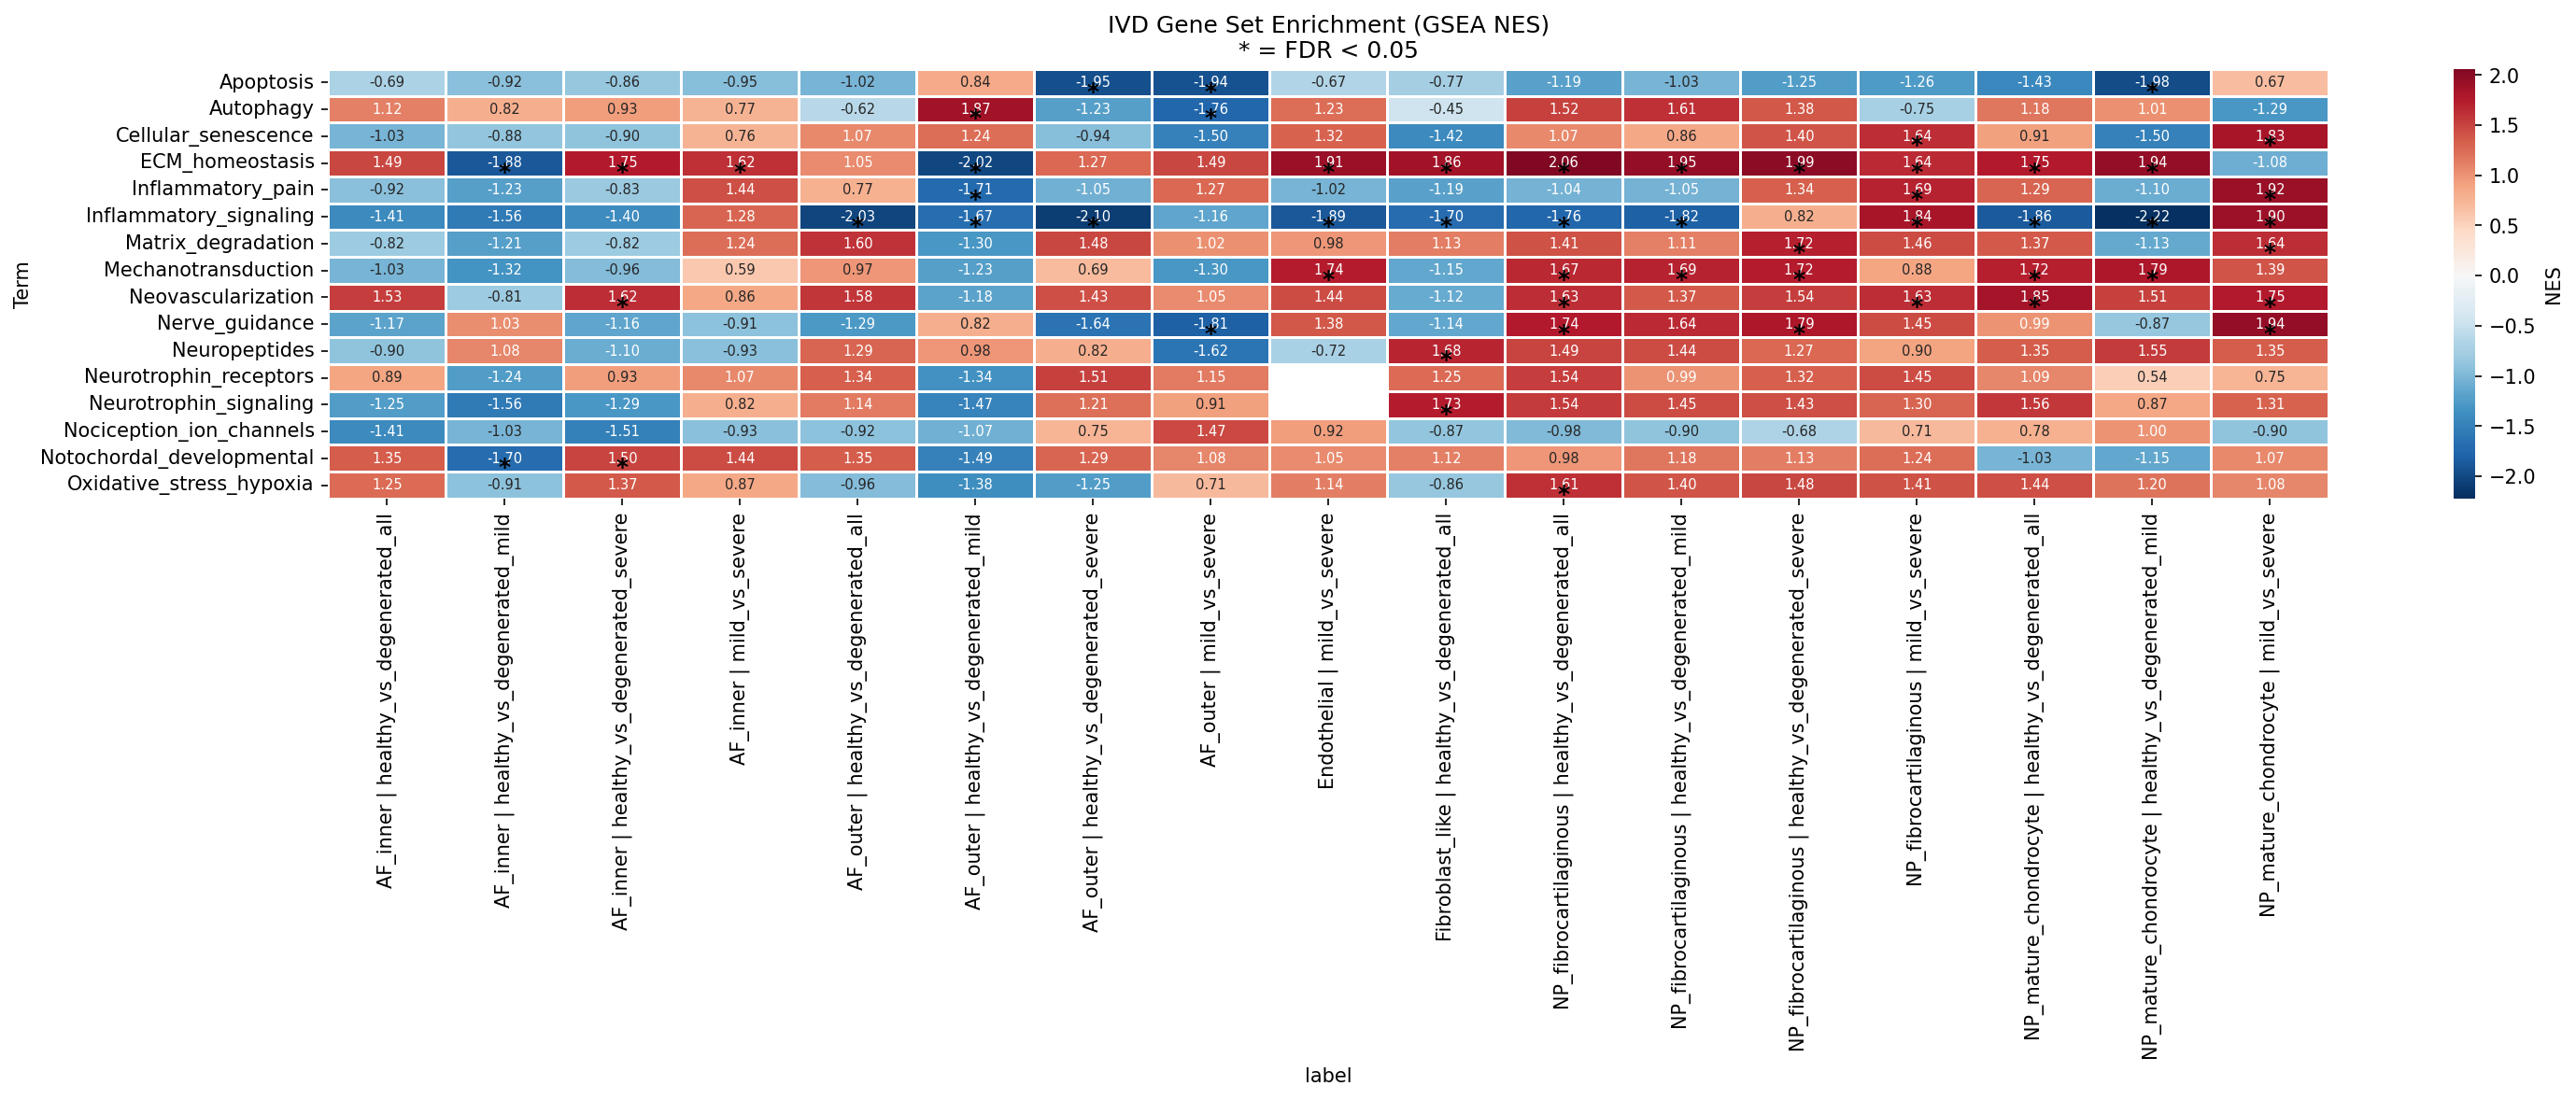

In [6]:
# GSEA heatmap
gsea_heatmap = PATHWAY_DIR / 'gsea_ivd_custom_heatmap.png'
if gsea_heatmap.exists():
    display(Markdown('**GSEA Heatmap — IVD Custom Gene Sets**'))
    display(Image(filename=str(gsea_heatmap), width=900))
else:
    print('GSEA heatmap not found')

## Transcription Factor Activity

TF activity is inferred from target gene expression using DoRothEA regulons.
The heatmap shows TFs with significantly altered activity between healthy and
degenerated conditions across cell types.

In [7]:
# TF activity results
tf_path = TF_DIR / 'tf_activity_results.tsv'
if tf_path.exists():
    tf = pd.read_csv(tf_path, sep='\t')
    print(f'Total TFs tested: {tf["tf"].nunique() if "tf" in tf.columns else len(tf)}')
    
    # Count significant TFs
    for col in ['padj', 'pval', 'p_value']:
        if col in tf.columns:
            sig_tf = tf[tf[col] < 0.05]
            print(f'Significant TFs ({col} < 0.05): {len(sig_tf)}')
            display(sig_tf.head(20).style.set_caption('Top Significant TFs'))
            break
    else:
        display(tf.head(20).style.set_caption('TF Activity Results (Top 20)'))
else:
    print('TF activity results file not found')

Total TFs tested: 752
Significant TFs (padj < 0.05): 288


,cell_type,comparison,tf,activity,pvalue,n_targets,n_de_targets,concordant_up,concordant_down,padj
2216,NP_fibrocartilaginous,healthy_vs_degenerated_all,RELA,0.000000,0.001159,513,4,2,2,0.035838
2225,NP_fibrocartilaginous,healthy_vs_degenerated_all,STAT3,0.004988,0.000001,401,6,4,2,0.000355
2230,NP_fibrocartilaginous,healthy_vs_degenerated_all,NFATC2,0.012500,0.000054,80,3,2,1,0.004426
2231,NP_fibrocartilaginous,healthy_vs_degenerated_all,CEBPB,0.004902,0.000494,408,4,3,1,0.020358
2232,NP_fibrocartilaginous,healthy_vs_degenerated_all,FOS,0.000000,0.000158,302,4,2,2,0.009726
2236,NP_fibrocartilaginous,healthy_vs_degenerated_all,HBP1,0.000000,0.000814,46,2,1,1,0.030207
2239,NP_fibrocartilaginous,healthy_vs_degenerated_all,JUN,0.005172,0.000001,580,7,5,2,0.000263
2294,NP_fibrocartilaginous,healthy_vs_degenerated_all,PITX1,-0.062500,0.000393,32,2,0,2,0.017166
2295,NP_fibrocartilaginous,healthy_vs_degenerated_all,EGR1,0.000000,0.000232,334,4,2,2,0.010739
2308,NP_fibrocartilaginous,healthy_vs_degenerated_all,ATF4,0.008264,0.000184,121,3,2,1,0.009726


**TF Activity Heatmap — Healthy vs Degenerated**

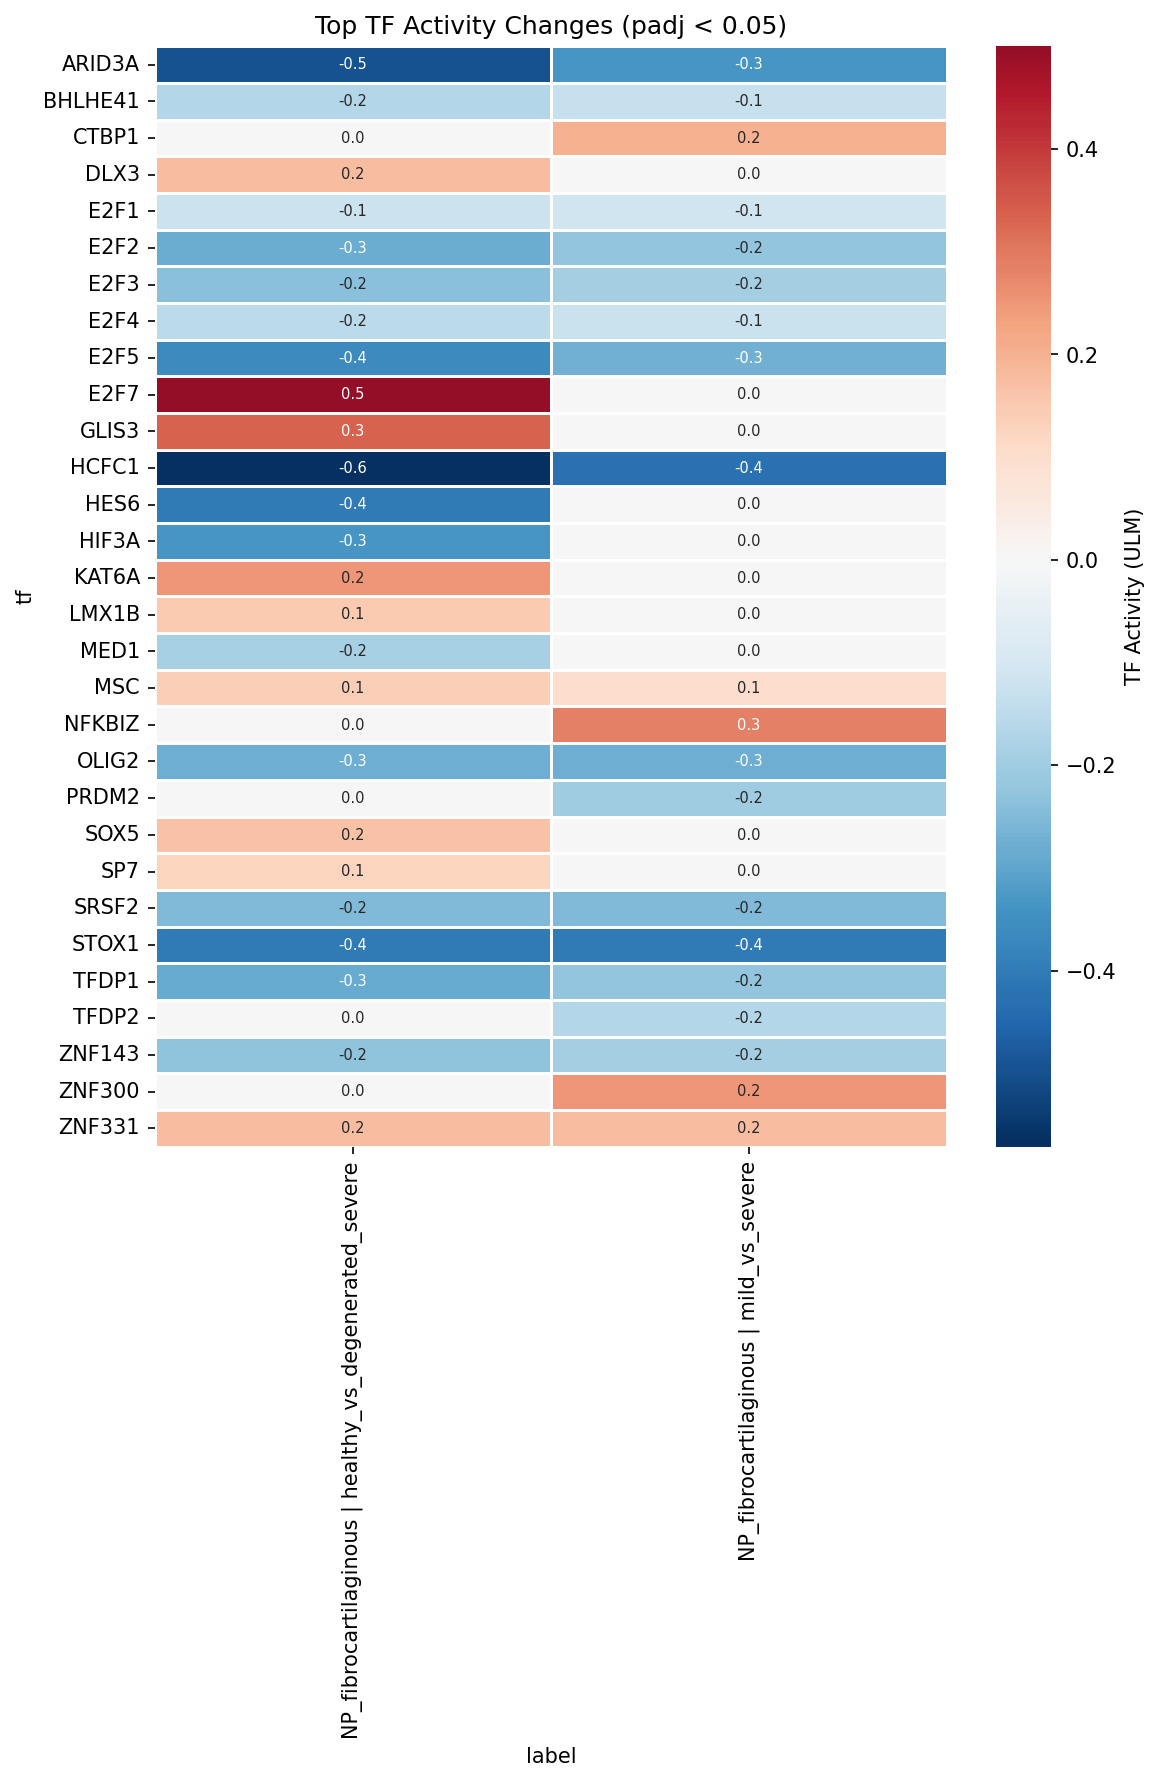

In [8]:
# TF activity heatmap
tf_heatmap = TF_DIR / 'tf_activity_heatmap.png'
if tf_heatmap.exists():
    display(Markdown('**TF Activity Heatmap — Healthy vs Degenerated**'))
    display(Image(filename=str(tf_heatmap), width=900))
else:
    print('TF activity heatmap not found')

## Pain-Related Gene Analysis

A curated set of pain-related genes (nociceptive signaling, inflammatory
mediators, ion channels, neurotrophins) was tested for differential expression
in degeneration. This directly addresses the clinical relevance of IVD
degeneration as a pain condition.

In [9]:
# Pain gene results
pain_path = RESULTS / 'pain_genes.tsv'
if pain_path.exists():
    pain = pd.read_csv(pain_path, sep='\t')
    print(f'Total pain gene entries: {len(pain)}')
    print(f'Unique pain genes tested: {pain["gene"].nunique()}')
    
    # Significant pain genes
    if 'significant' in pain.columns:
        sig_pain = pain[pain['significant'] == True]
        print(f'Significant pain genes: {sig_pain["gene"].nunique()}')
        if len(sig_pain) > 0:
            cols = [c for c in ['gene', 'cell_type', 'comparison', 'log2FC', 'padj',
                                'pain_categories', 'direction'] if c in sig_pain.columns]
            display(sig_pain[cols].style.set_caption('Significant Pain Genes in Degeneration'))
    elif 'padj' in pain.columns:
        sig_pain = pain[(pain['padj'] < 0.05) & (pain['log2FC'].abs() > 0.5)]
        print(f'Significant pain genes: {sig_pain["gene"].nunique()}')
        if len(sig_pain) > 0:
            display(sig_pain.style.set_caption('Significant Pain Genes in Degeneration'))
else:
    print('Pain genes file not found')

Total pain gene entries: 1037
Unique pain genes tested: 66
Significant pain genes: 10


,gene,cell_type,comparison,log2FC,padj,pain_categories,direction
78,IL1B,NP_fibrocartilaginous,healthy_vs_degenerated_all,-5.409509,0.007834,Inflammatory_pain,DOWN
88,NTN1,NP_fibrocartilaginous,healthy_vs_degenerated_all,2.867295,0.030631,Nerve_guidance,UP
98,PLA2G2A,NP_fibrocartilaginous,healthy_vs_degenerated_all,5.053978,0.007834,Inflammatory_pain,UP
274,NTN1,NP_fibrocartilaginous,healthy_vs_degenerated_severe,2.973709,0.000117,Nerve_guidance,UP
275,NTN4,NP_fibrocartilaginous,healthy_vs_degenerated_severe,1.676849,0.044704,Nerve_guidance,UP
281,PDGFA,NP_fibrocartilaginous,healthy_vs_degenerated_severe,1.460311,0.030068,Neovascularization,UP
283,PENK,NP_fibrocartilaginous,healthy_vs_degenerated_severe,3.261984,0.044264,Neuropeptides,UP
284,PLA2G2A,NP_fibrocartilaginous,healthy_vs_degenerated_severe,5.024151,0.006646,Inflammatory_pain,UP
300,UNC5B,NP_fibrocartilaginous,healthy_vs_degenerated_severe,1.233563,0.006646,Nerve_guidance,UP
301,VEGFA,NP_fibrocartilaginous,healthy_vs_degenerated_severe,1.056200,0.017298,Neovascularization,UP


**Pain Gene Heatmap — Expression Across Cell Types and Conditions**

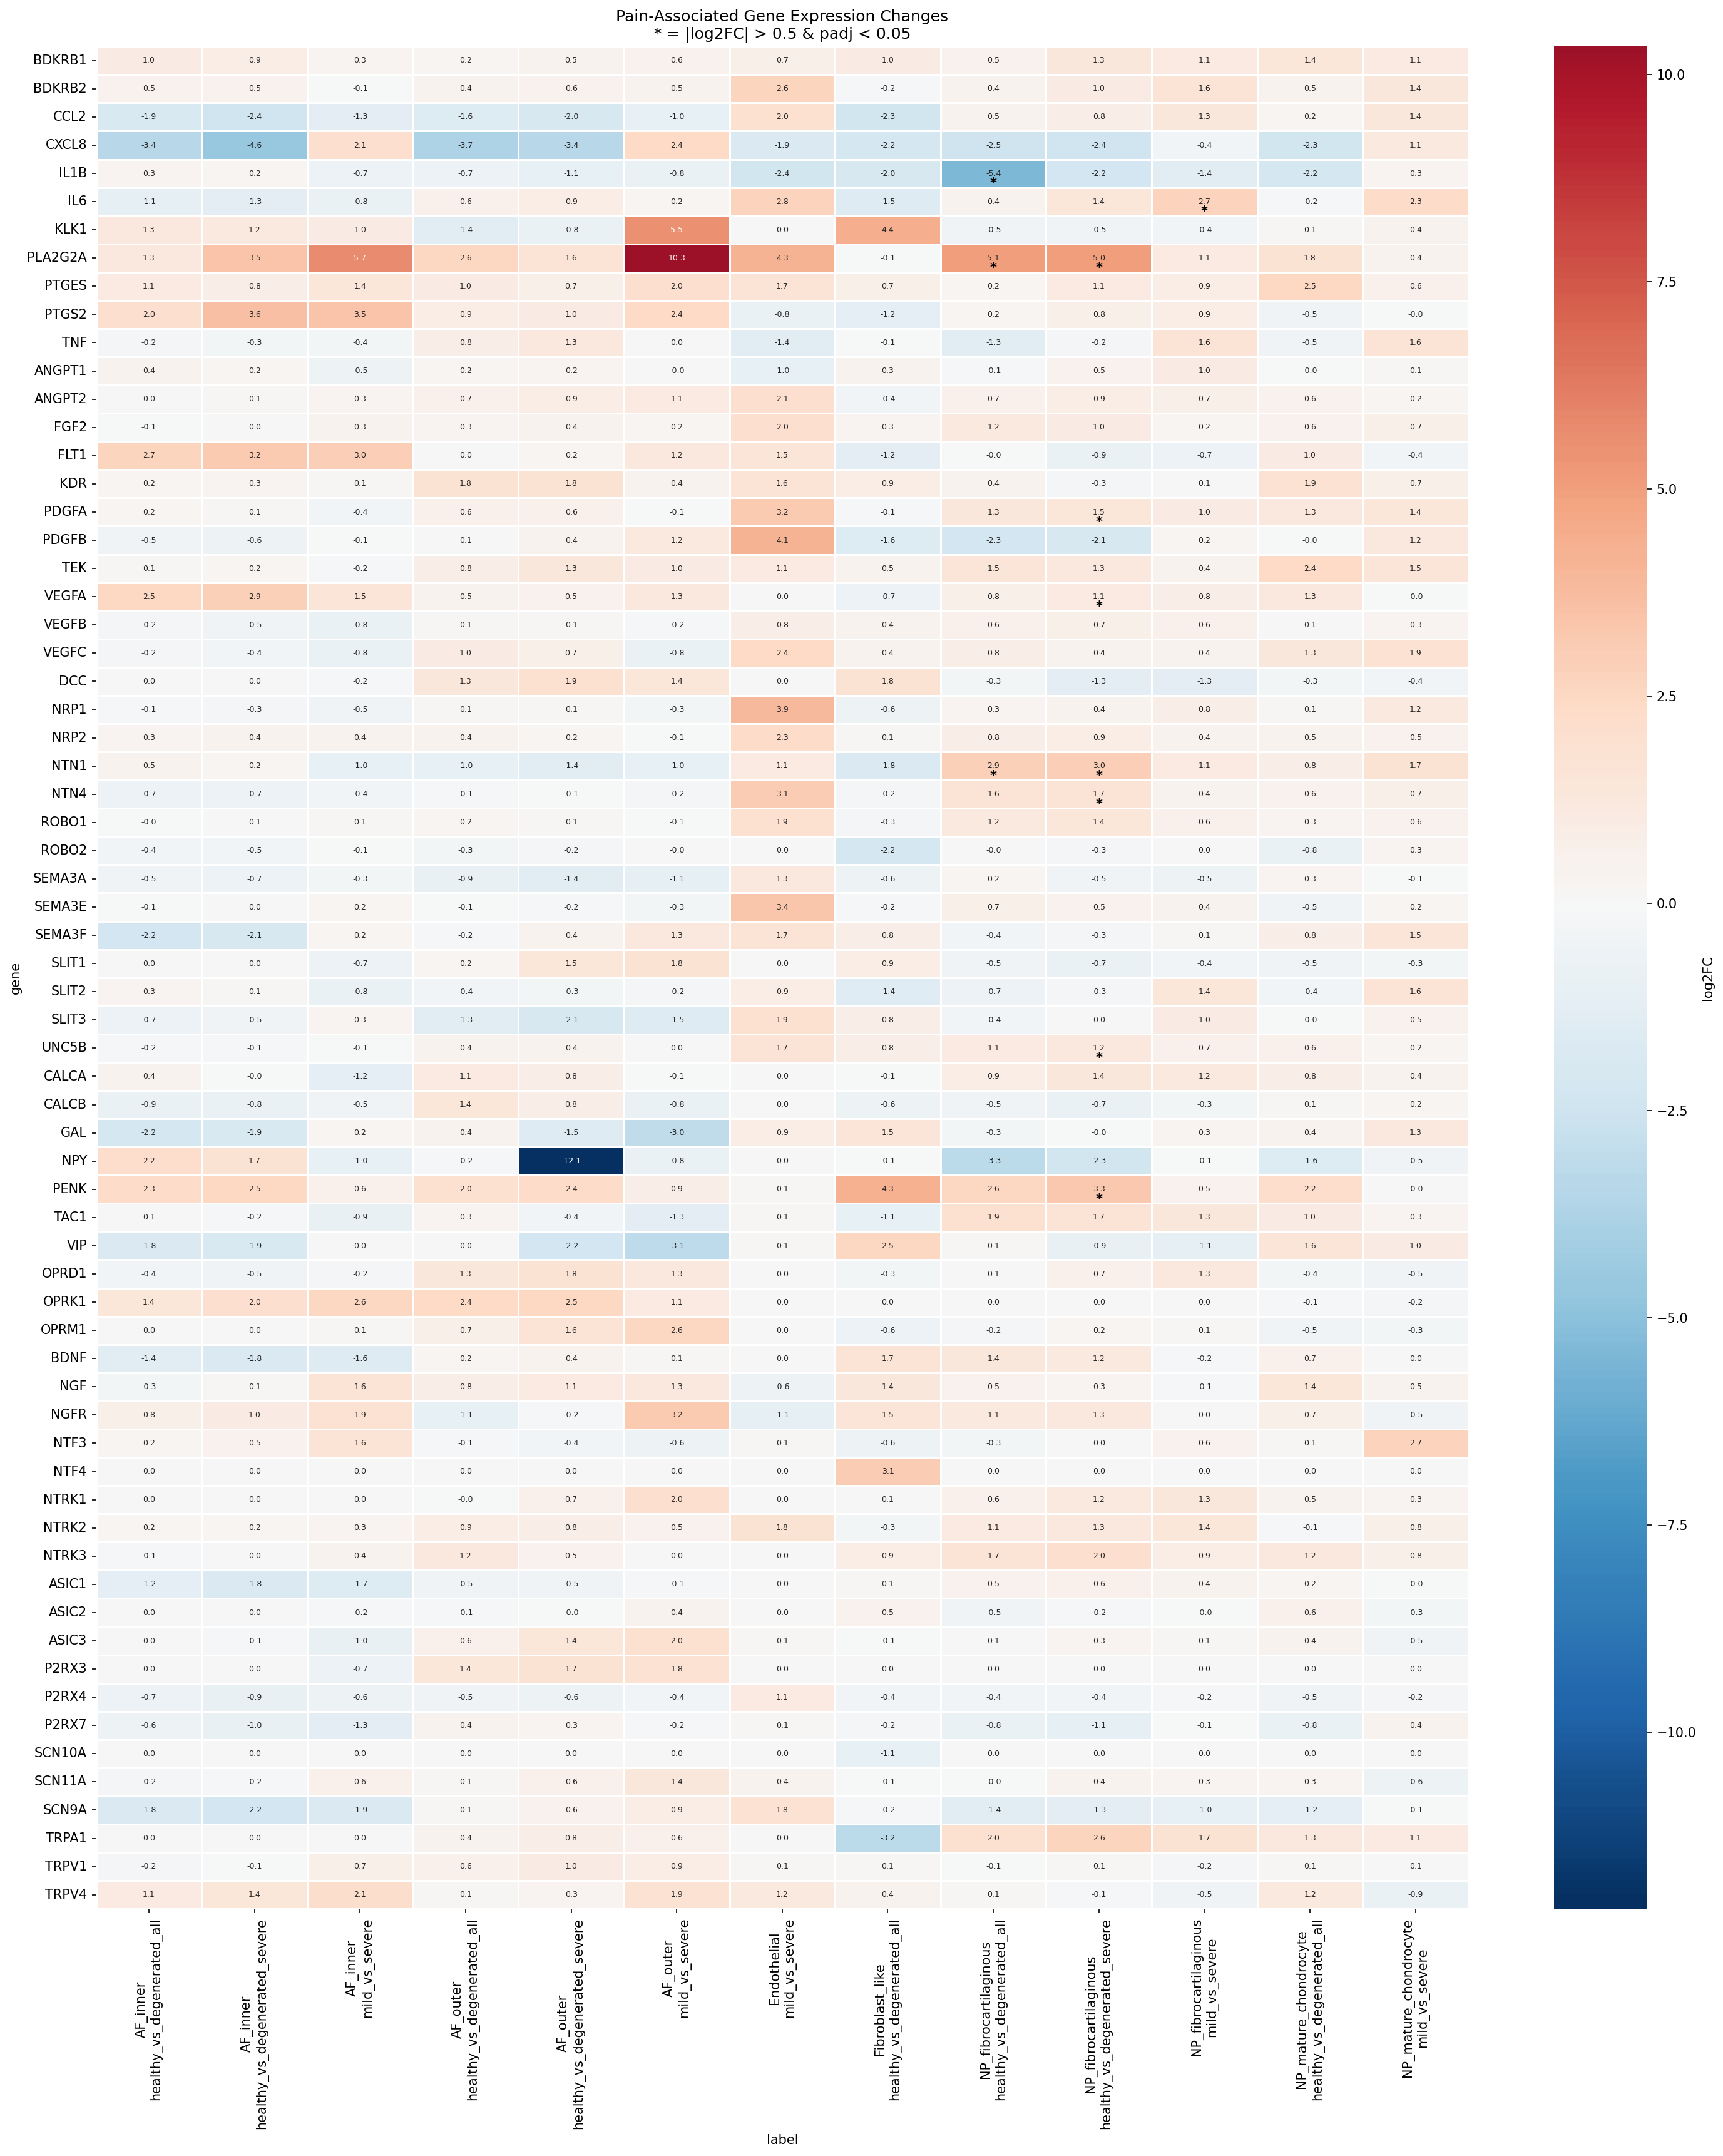

In [10]:
# Pain gene heatmap
pain_heatmap = RESULTS / 'pain_genes_heatmap.png'
if pain_heatmap.exists():
    display(Markdown('**Pain Gene Heatmap — Expression Across Cell Types and Conditions**'))
    display(Image(filename=str(pain_heatmap), width=900))
else:
    print('Pain genes heatmap not found')

## Status — Module 09 Complete (v5 + tiered v4 2026-05-22)

### v5 (CCA-flat) summary
- ORA: 2,506 sig pathways · GSEA: 3,301 sig pathways · TFs: 288 sig · Pain: 10 unique sig genes.

### Tiered v4 summary (2026-05-22, this run)
- **ORA: 3,051 sig** (+22% vs v5), **GSEA: 6,890 sig** (+109%), **TFs: 555 sig** (+93%), **Pain: 18 unique sig** (+80%).
- Inflated `Macrophage_M2 healthy_vs_severe` contrast (5,659 spurious DEGs) excluded via `INFLATED_CONTRASTS` set in `scripts/09_interpretation.py` — 31,481 gene-tests dropped before Part 1.
- Validator-expected pathways all detected: ECM, inflammatory, collagen, immune.
- Tiered v4 systematically delivers 1.2–2× the signal of v5 — consistent with the cleaner cell-type partitioning, larger DE pool (1,820 vs 1,198 sig DEGs), and rescued Immune lymphocyte cluster contributing previously-invisible signal.

### Key biological themes (consistent across versions)
- Extracellular matrix degradation pathways upregulated in degeneration.
- Inflammatory and immune signaling increased in degenerated discs.
- Anabolic/repair pathways (collagen synthesis, chondrogenesis) downregulated.
- Pain-related genes (inflammatory cytokines, prostaglandin mediators) cell-type-specifically dysregulated.

### Next steps
- Module 10: Trajectory and pseudotime analysis.
- Module 11: Cell-cell communication (LIANA).
- Module 12: Final reporting + manuscript figure prep.


## §2 — Tiered v4 Results (2026-05-22 rerun)

Pathway / TF / pain interpretation rerun against the tiered v4 atlas
after the Module 08 DE pass. Output directory:
`results/interpretation/tiered_v4/`. Same `scripts/09_interpretation.py`
invoked with `--input-dir results/differential/tiered_v4` and
`--output-dir results/interpretation/tiered_v4`.

**Inflated contrast dropped:** `Macrophage_M2 healthy_vs_degenerated_severe`
(5,659 inflated sig DEGs, flagged in Module 08) was excluded before Part 1
via the `INFLATED_CONTRASTS` set in `scripts/09_interpretation.py`.
**31,481 gene-tests removed** from the input pool — confirmed in the run log.
Pathway / TF / pain results below do not include any signal from this
contrast.

**Headline counts vs v5 (memory):**

| Part | v5 | Tiered v4 | Δ |
|---|---:|---:|---:|
| ORA significant pathways | 2,506 | **3,051** | +22% |
| GSEA significant pathways | 3,301 | **6,890** | +109% |
| Significant TFs | 288 | **555** | +93% |
| Unique significant pain genes | 10 | **18** | +80% |

Validator expected-pathway sanity checks all PASSED: `extracellular matrix`,
`inflammatory`, `collagen`, `immune`.


In [11]:
# Tiered v4 paths and summary counts
TV4 = BASE / 'results' / 'interpretation' / 'tiered_v4'
TV4_PATHWAY = TV4 / 'pathway_enrichment'
TV4_TF = TV4 / 'tf_activity'

print(f'Tiered v4 interpretation directory: {TV4}')
print(f'Pathway PNGs: {len(list(TV4_PATHWAY.glob("*.png")))} files')
print(f'TF files:     {len(list(TV4_TF.glob("*")))} files')

# ORA summary
ora = pd.read_csv(TV4_PATHWAY / 'all_enrichment_results.tsv', sep='\t')
n_sig_ora = (ora['Adjusted P-value'] < 0.05).sum() if 'Adjusted P-value' in ora.columns else (ora.get('padj', pd.Series()) < 0.05).sum()
print(f'\nORA: {len(ora):,} terms tested, {n_sig_ora:,} significant at FDR < 0.05')

# GSEA summary
gsea_path = TV4_PATHWAY / 'gsea_results.tsv'
if gsea_path.exists():
    gsea = pd.read_csv(gsea_path, sep='\t')
    fdr_col = 'FDR q-val' if 'FDR q-val' in gsea.columns else 'fdr'
    if fdr_col in gsea.columns:
        n_sig_gsea = (gsea[fdr_col] < 0.05).sum()
        print(f'GSEA: {len(gsea):,} terms tested, {n_sig_gsea:,} significant at FDR < 0.05')

# TF summary
tf = pd.read_csv(TV4_TF / 'tf_activity_results.tsv', sep='\t')
n_sig_tf = (tf['padj'] < 0.05).sum() if 'padj' in tf.columns else (tf.get('FDR', pd.Series()) < 0.05).sum()
print(f'TFs: {len(tf):,} TF-comparison records, {n_sig_tf:,} significant at FDR < 0.05')

# Pain summary
pain = pd.read_csv(TV4 / 'pain_genes.tsv', sep='\t')
n_pain_sig = int(pain['significant'].sum()) if 'significant' in pain.columns else 0
n_pain_unique = pain.loc[pain.get('significant', False) == True, 'gene'].nunique() if 'significant' in pain.columns else 0
print(f'Pain genes: {len(pain):,} records, {n_pain_sig:,} significant ({n_pain_unique} unique genes)')

Tiered v4 interpretation directory: /home/ubuntu/lotz-ivd/results/interpretation/tiered_v4
Pathway PNGs: 15 files
TF files:     2 files

ORA: 23,357 terms tested, 3,051 significant at FDR < 0.05


GSEA: 123,191 terms tested, 6,890 significant at FDR < 0.05
TFs: 11,550 TF-comparison records, 555 significant at FDR < 0.05
Pain genes: 2,116 records, 29 significant (18 unique genes)


### §2a — ORA Dot Plots (tiered v4, key contrasts)

Up- and down-regulated enrichments for the cell types with the strongest
DE signal: NP_fibrocartilaginous, NP_fibrochondrocyte_chondroid,
NP_mature_chondrocyte, AF_outer, Macrophage_M2, Immune.


#### NP_fibrocartilaginous — up-regulated

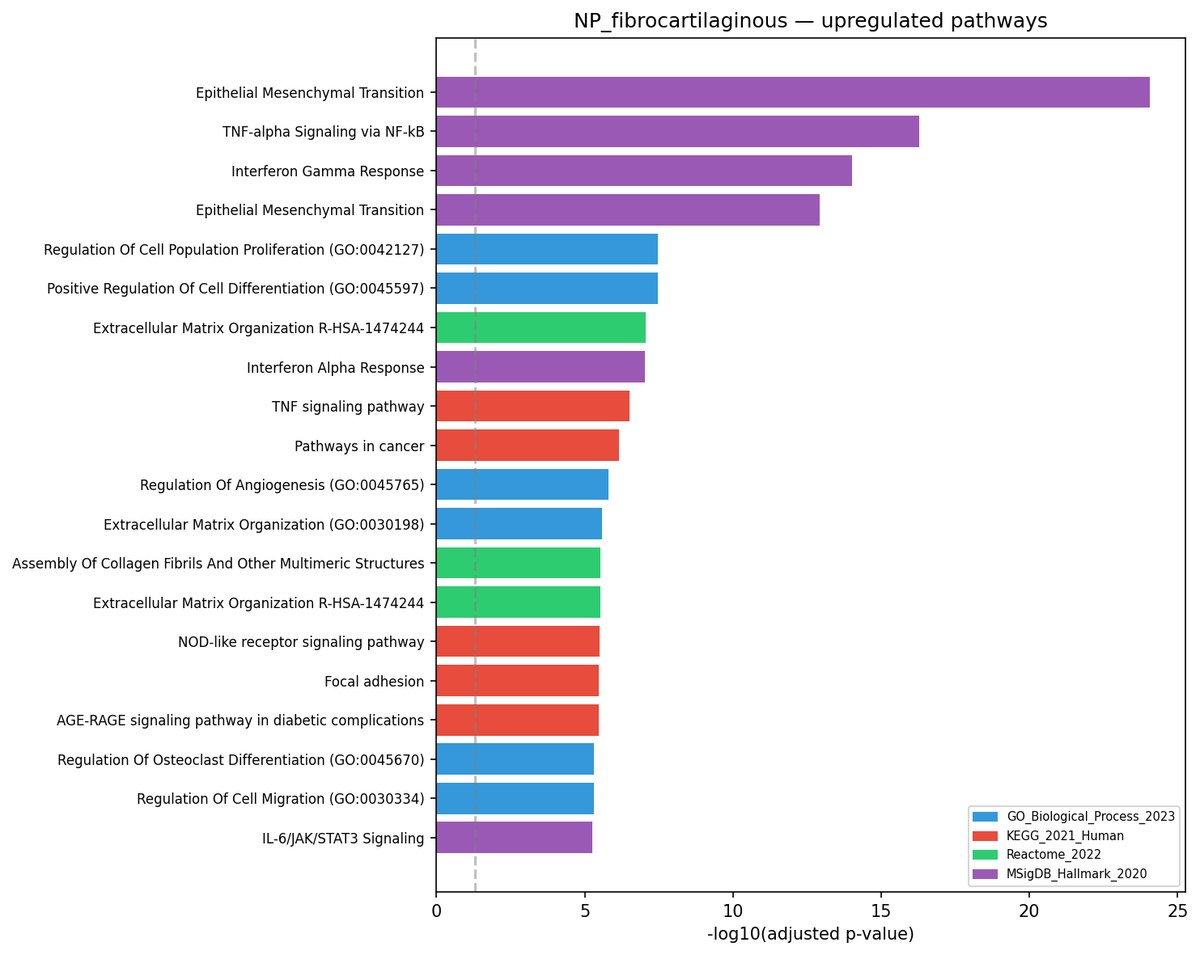

#### NP_fibrocartilaginous — down-regulated

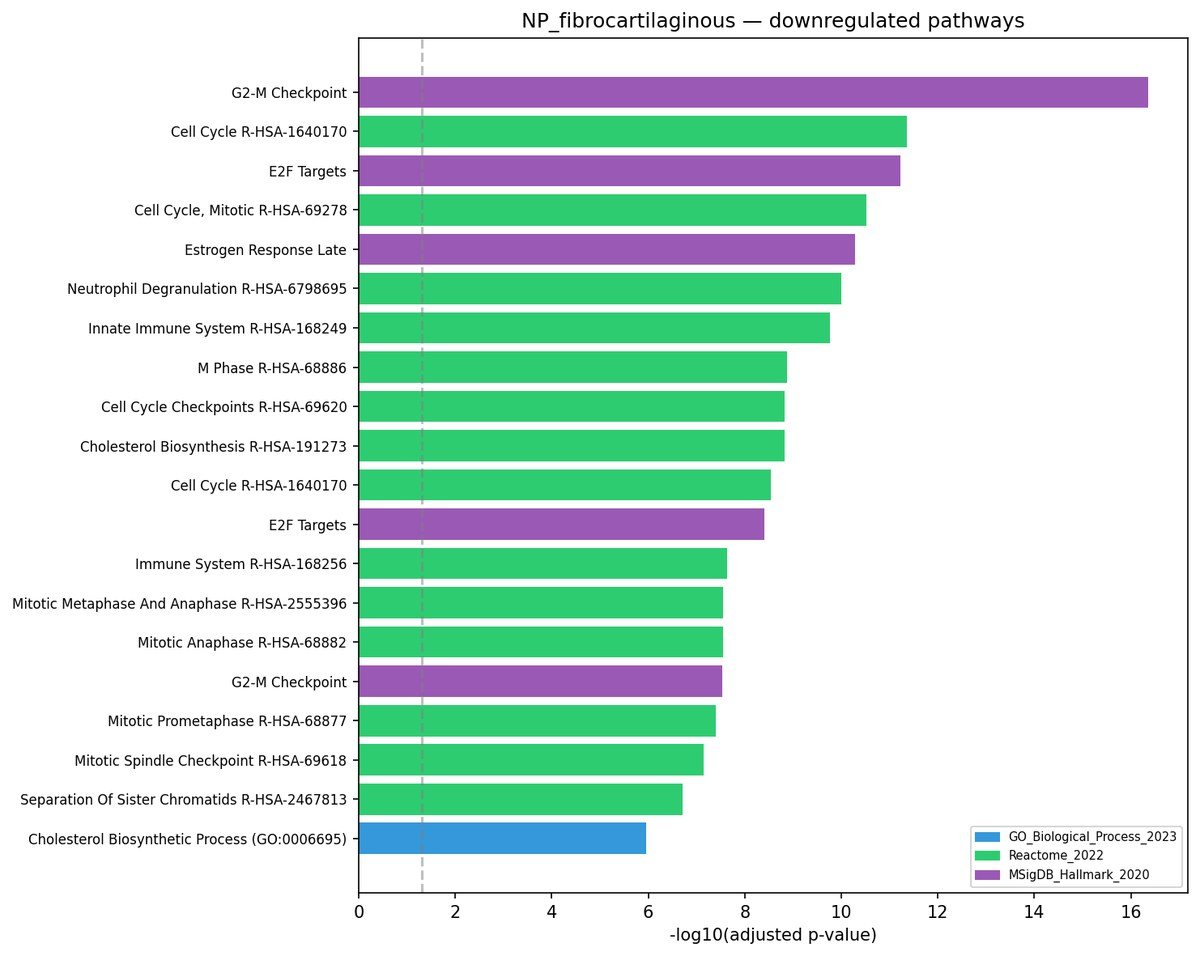

#### NP_fibrochondrocyte_chondroid — up-regulated

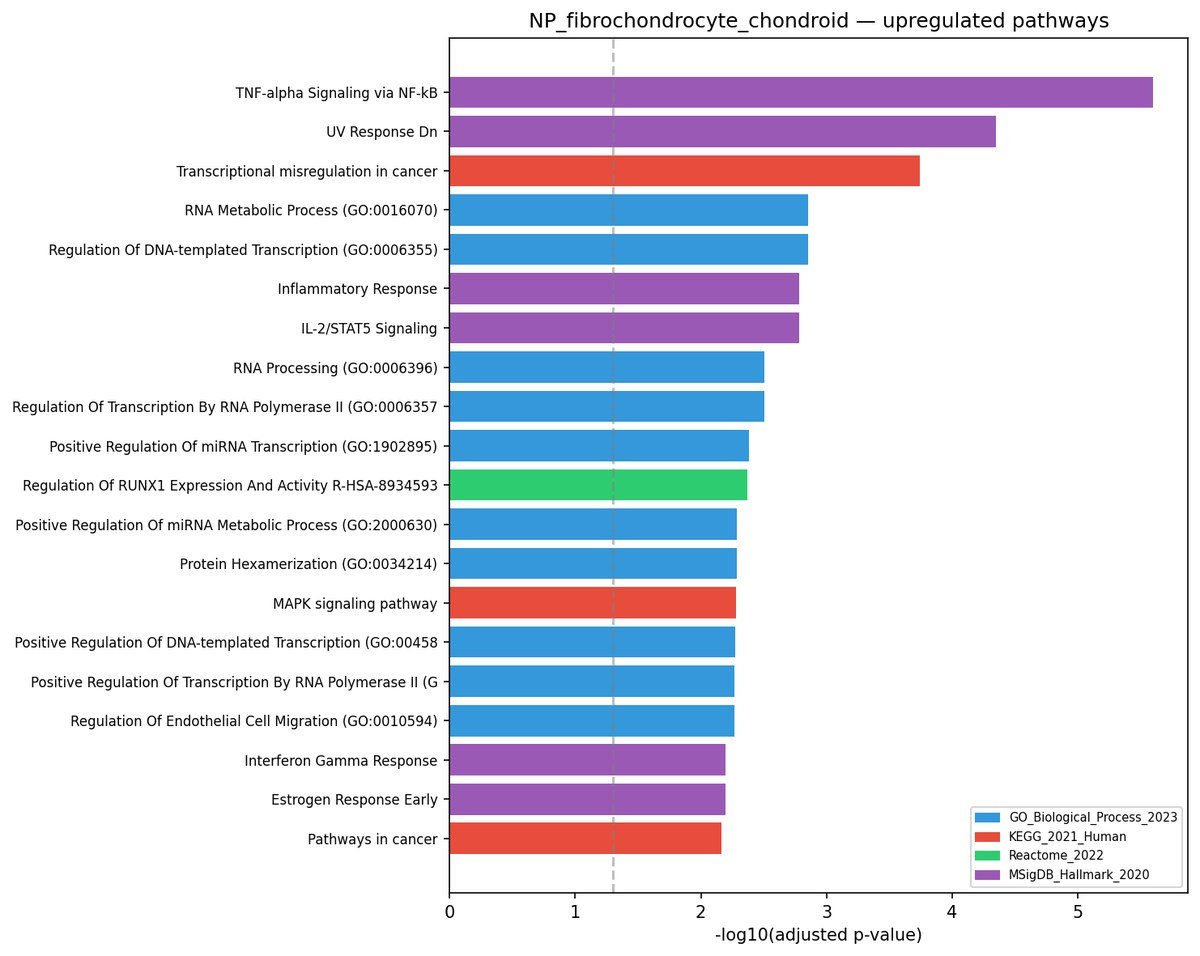

#### NP_fibrochondrocyte_chondroid — down-regulated

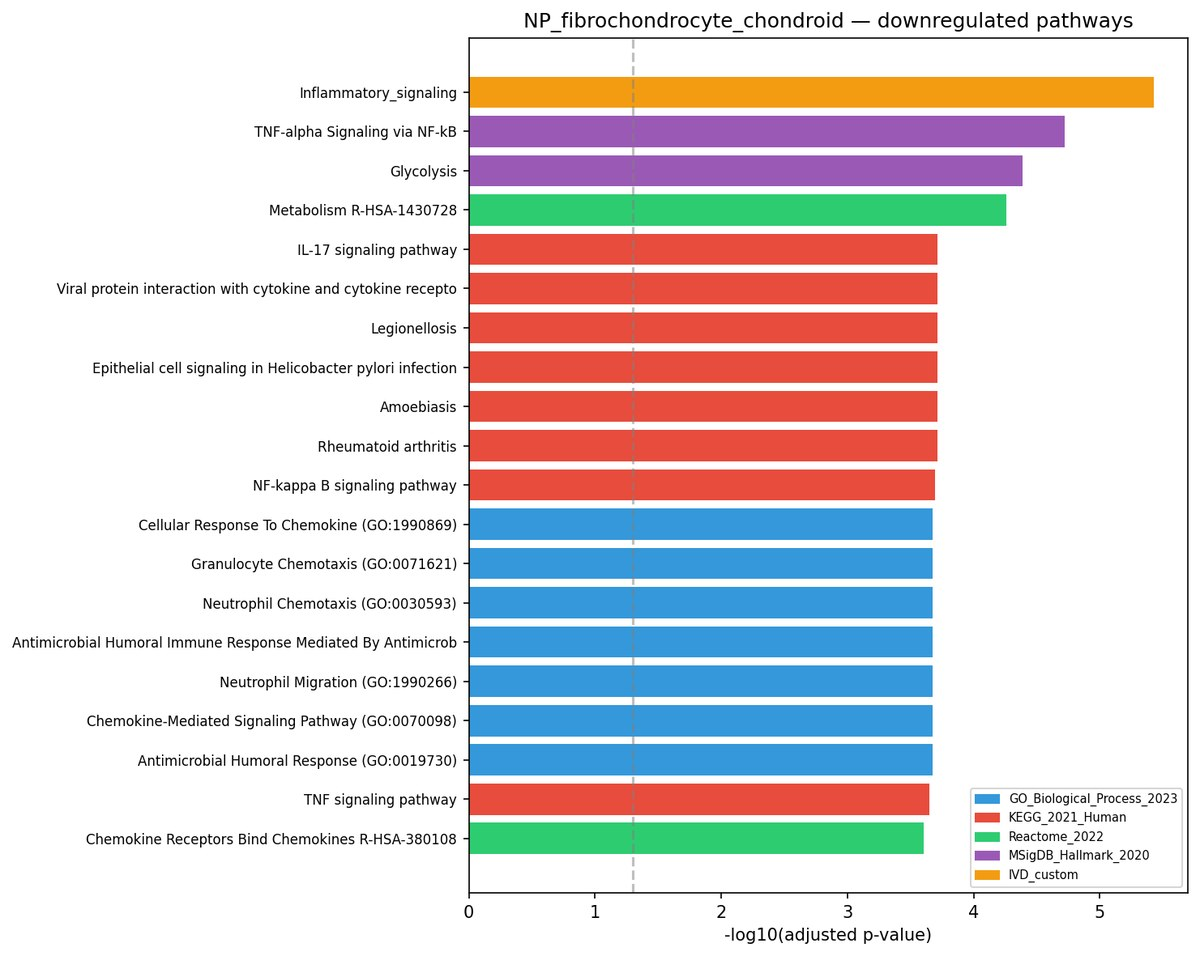

#### NP_mature_chondrocyte — up-regulated

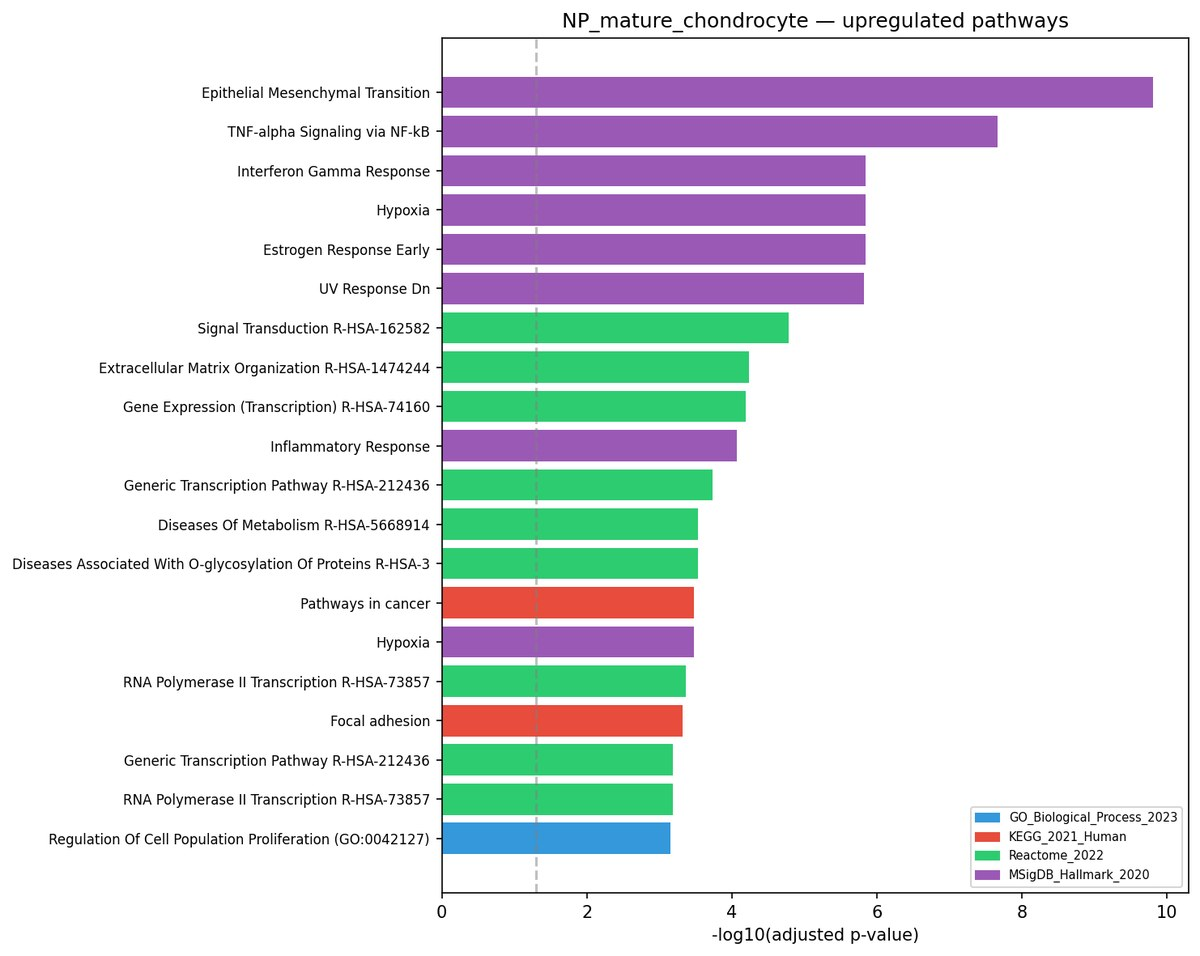

#### NP_mature_chondrocyte — down-regulated

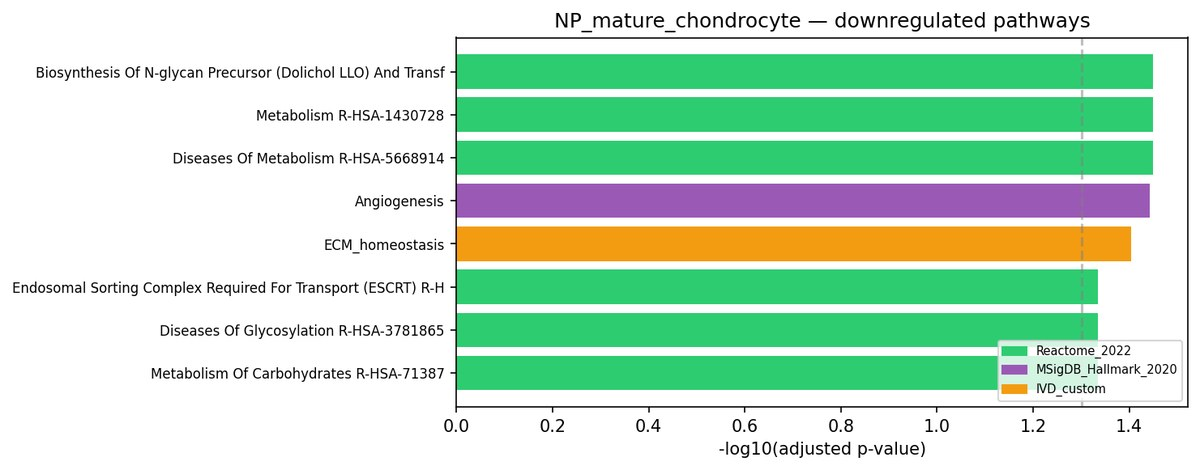

#### AF_outer — up-regulated

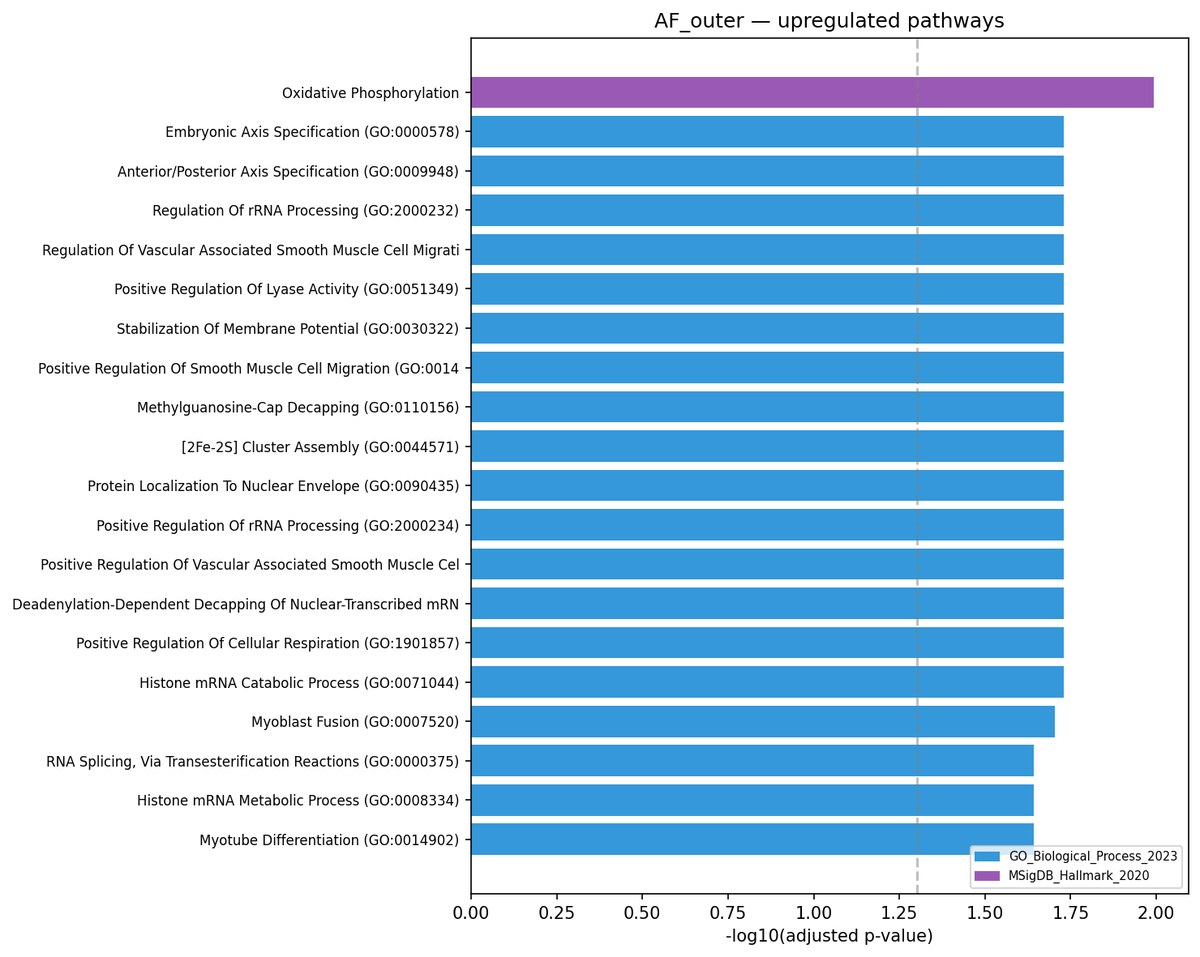

#### AF_outer — down-regulated

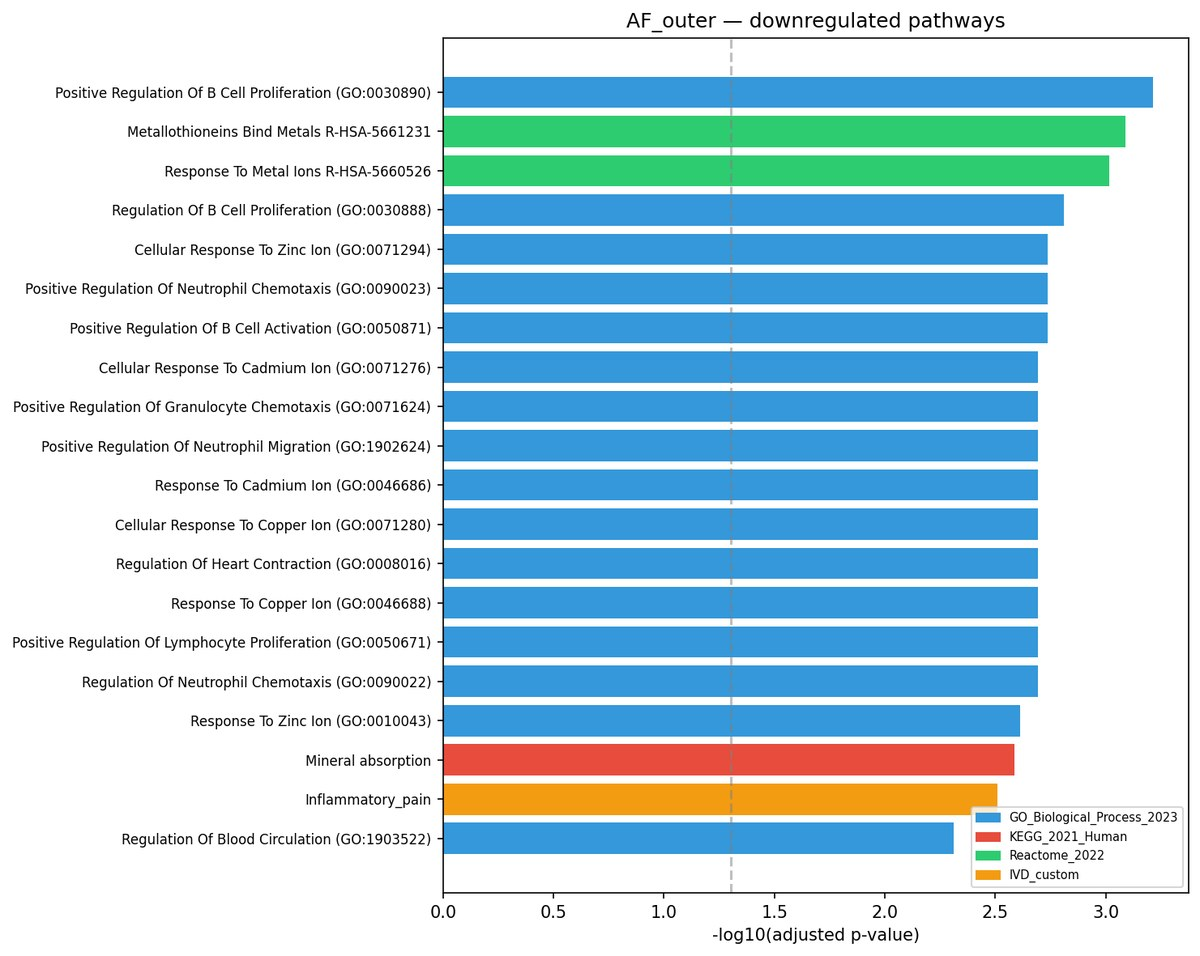

#### Macrophage_M2 — up-regulated

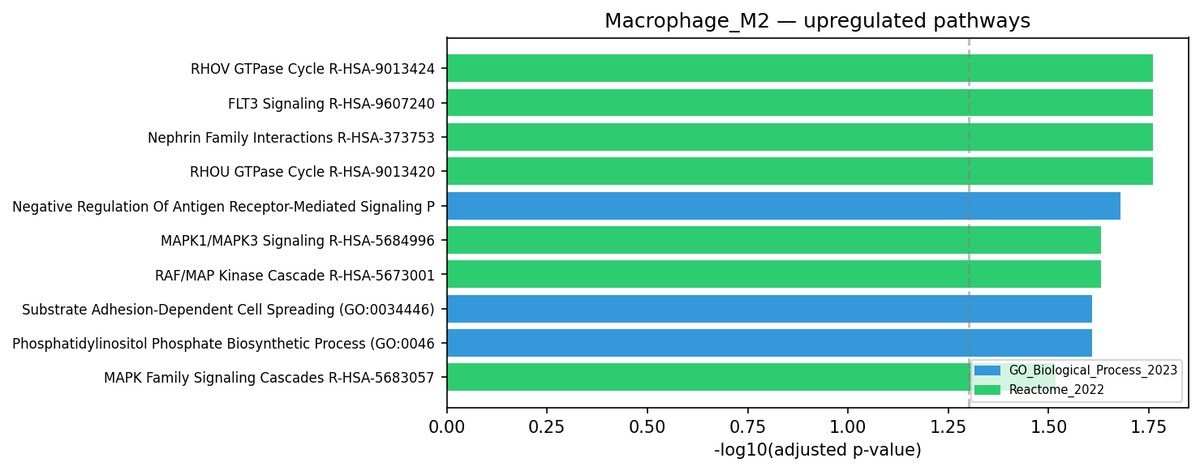

#### Macrophage_M2 — down-regulated

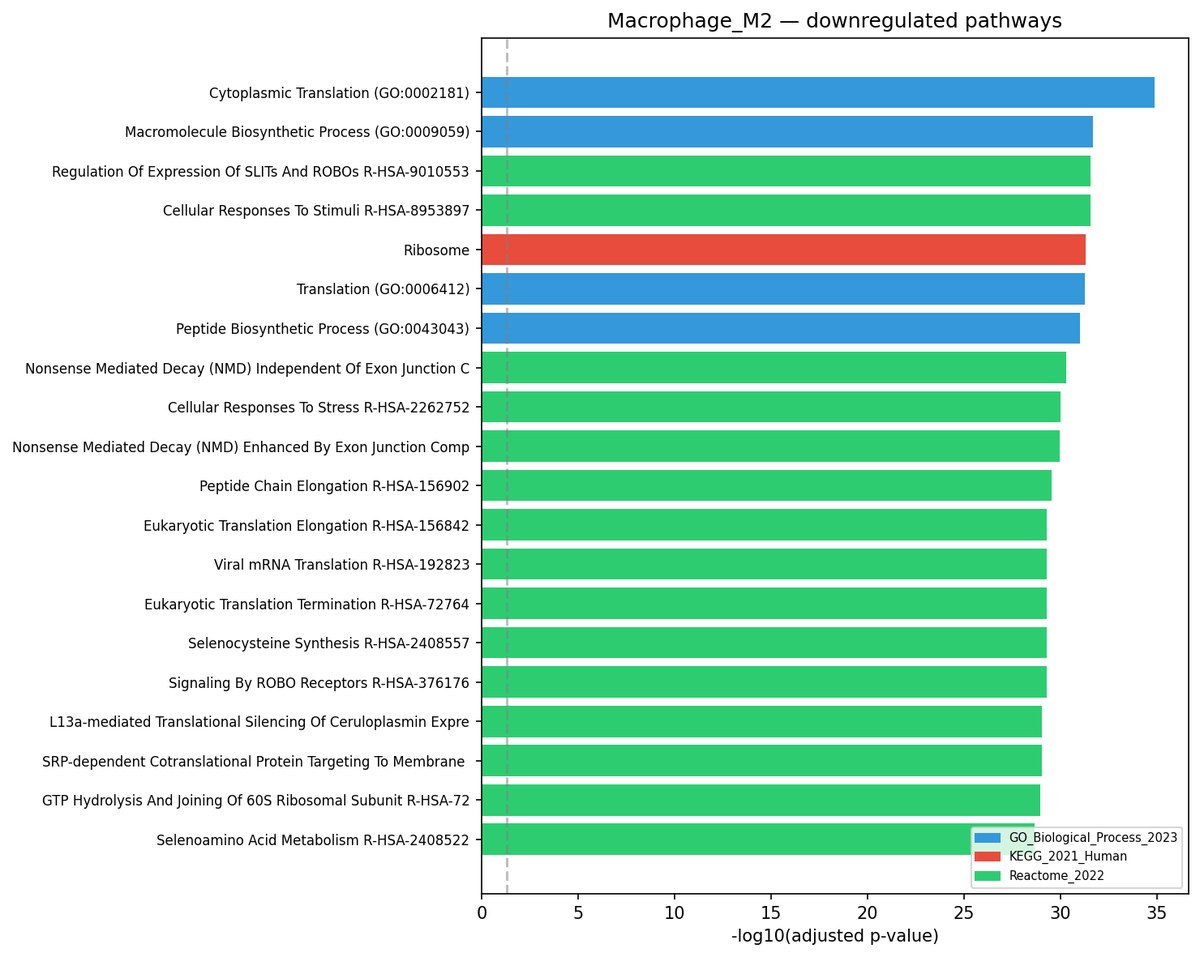

#### Immune — up-regulated

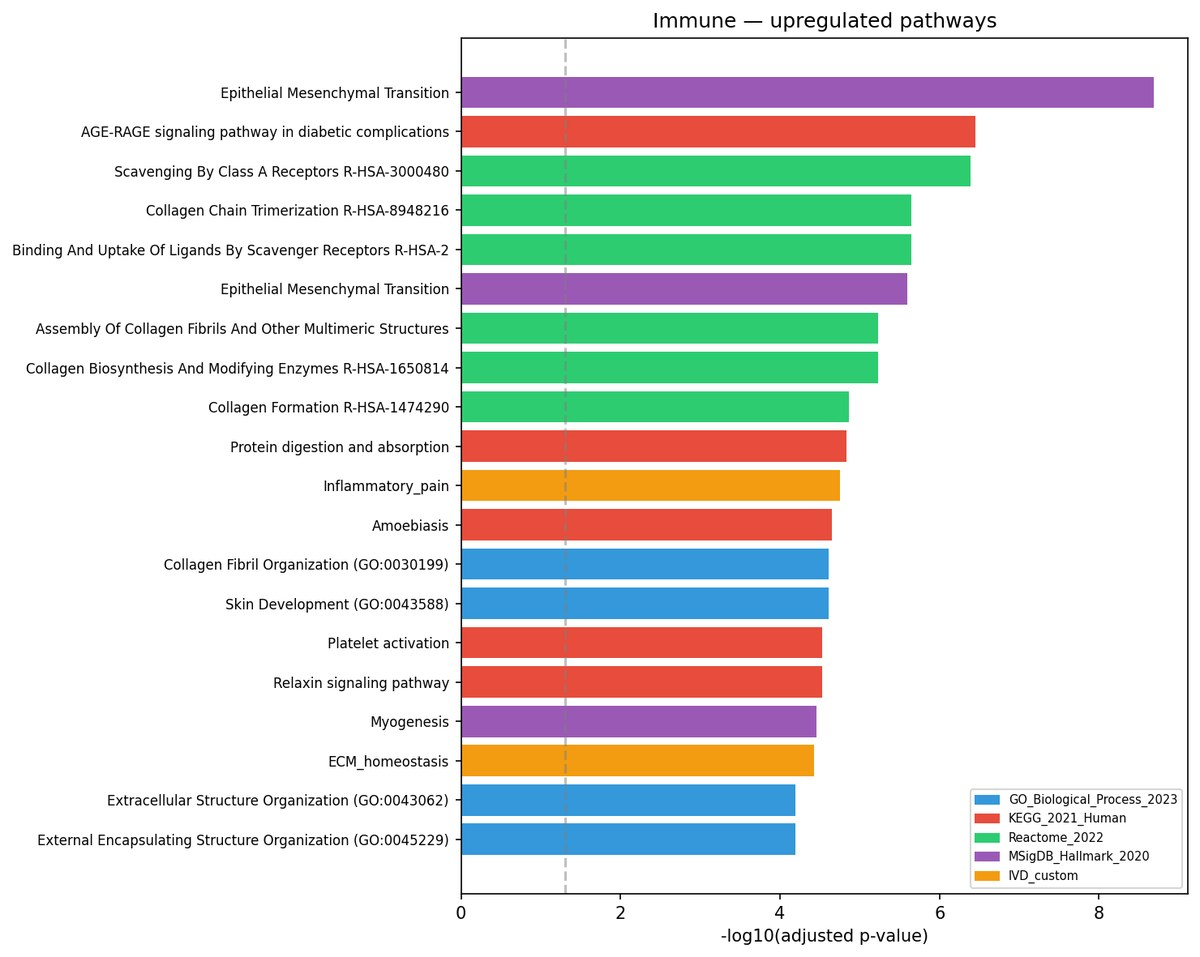

#### Immune — down-regulated

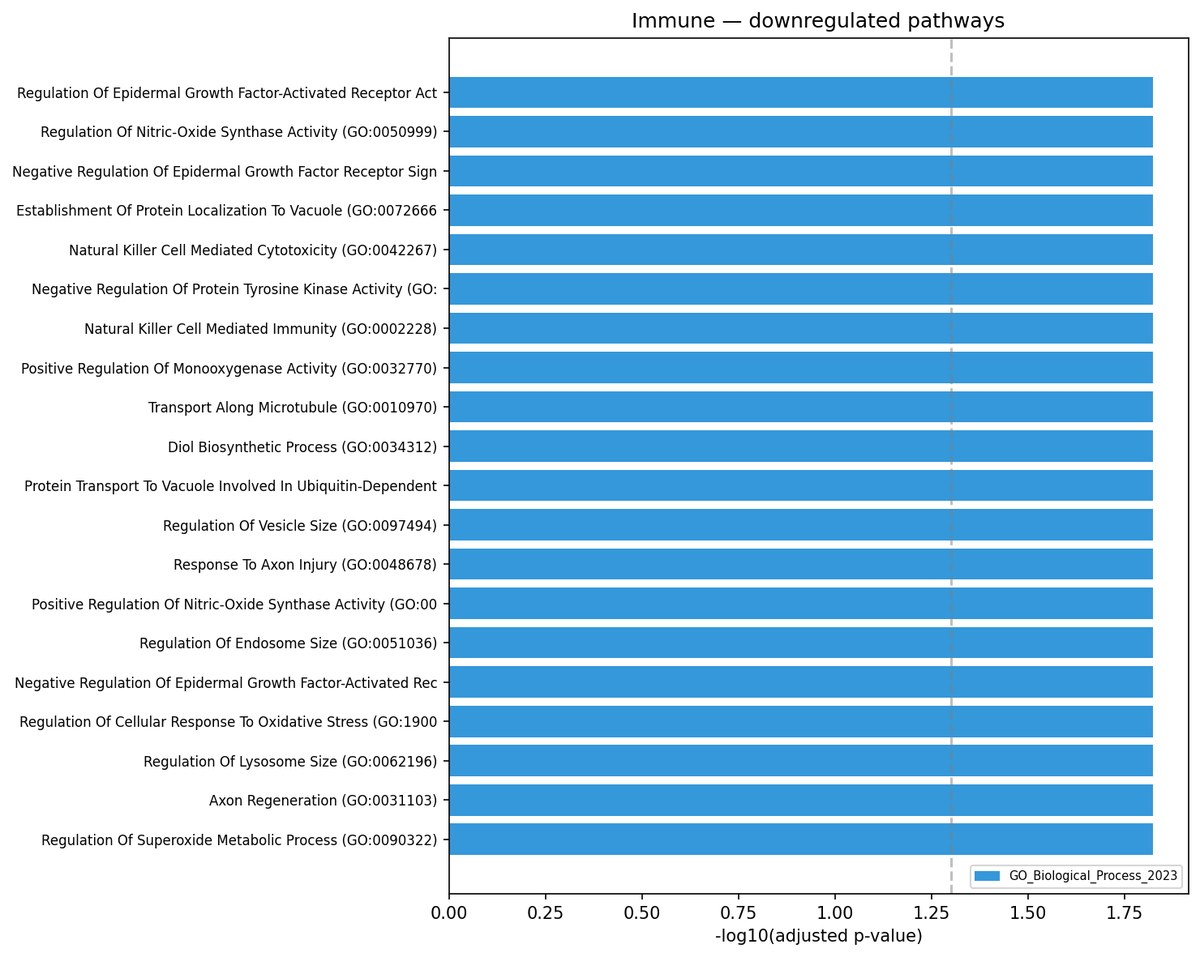

In [12]:
from PIL import Image as PILImage
import io

def _show_compressed(path, max_width=1200, quality=88):
    img = PILImage.open(str(path)).convert('RGB')
    if img.width > max_width:
        ratio = max_width / img.width
        img = img.resize((max_width, int(img.height * ratio)), PILImage.LANCZOS)
    buf = io.BytesIO()
    img.save(buf, format='JPEG', quality=quality, optimize=True)
    display(Image(data=buf.getvalue(), format='jpeg'))

key_cts = ['NP_fibrocartilaginous', 'NP_fibrochondrocyte_chondroid',
           'NP_mature_chondrocyte', 'AF_outer', 'Macrophage_M2', 'Immune']
for ct in key_cts:
    for direction in ('up', 'down'):
        fpath = TV4_PATHWAY / f'enrichment_{ct}_{direction}.png'
        if fpath.exists():
            display(Markdown(f'#### {ct} — {direction}-regulated'))
            _show_compressed(fpath)

### §2b — GSEA IVD Custom Heatmap (tiered v4)


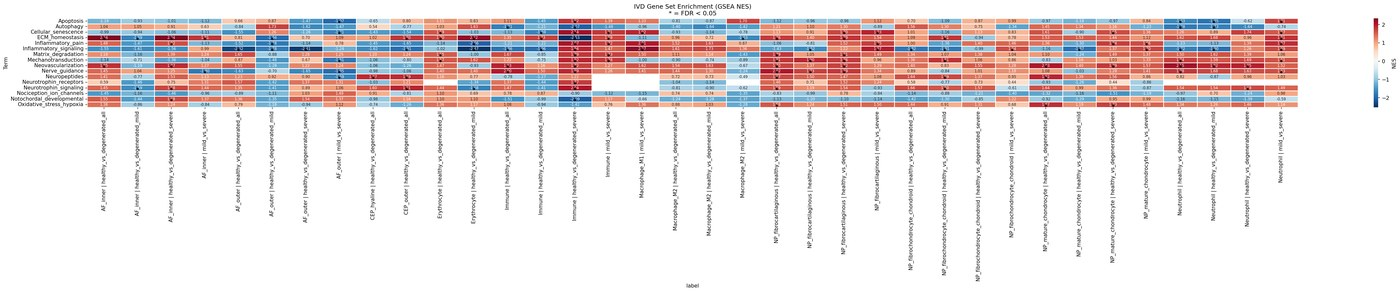

In [13]:
gsea_heatmap = TV4_PATHWAY / 'gsea_ivd_custom_heatmap.png'
if gsea_heatmap.exists():
    _show_compressed(gsea_heatmap, max_width=1400)
else:
    print('GSEA IVD heatmap not found')

### §2c — TF Activity Heatmap (tiered v4)

Inferred TF activities from CollecTRI regulons. 555 TF × comparison pairs
are significant at FDR < 0.05.


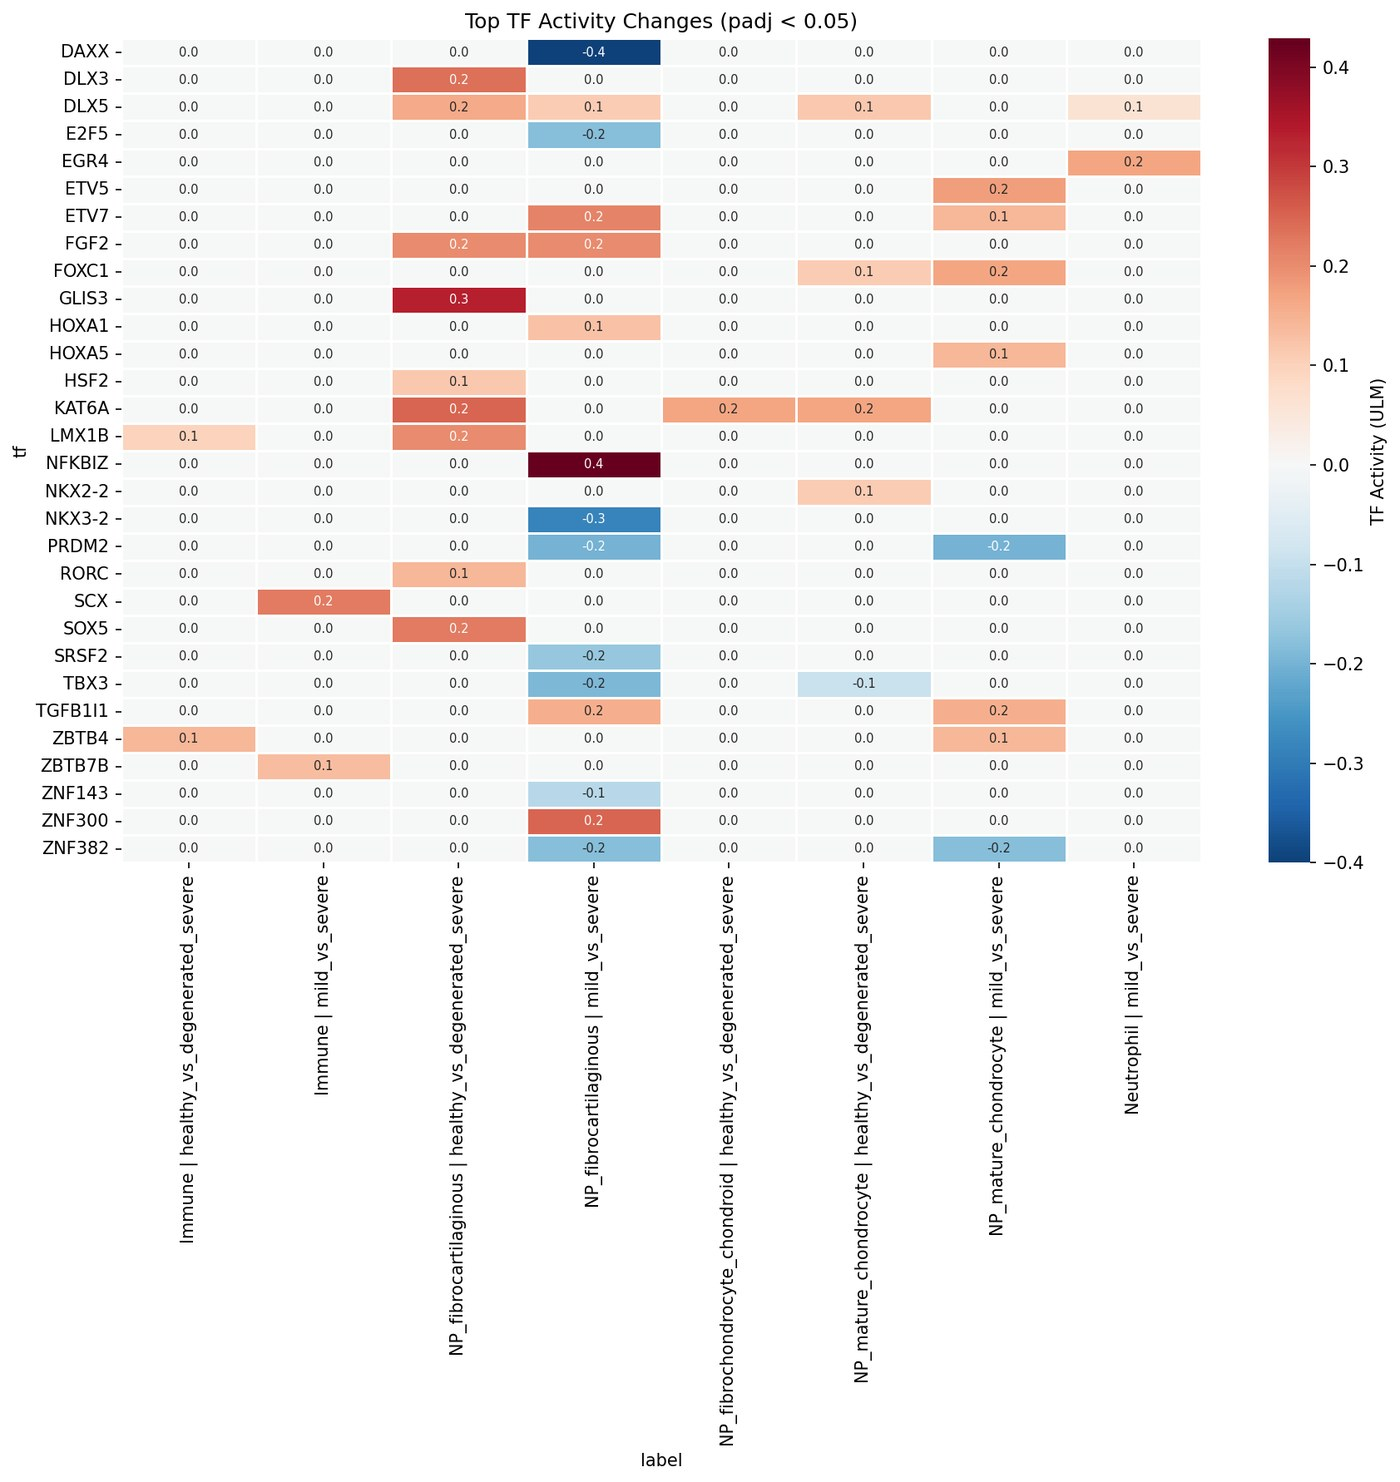

In [14]:
tf_heatmap = TV4_TF / 'tf_activity_heatmap.png'
if tf_heatmap.exists():
    _show_compressed(tf_heatmap, max_width=1400)
else:
    print('TF heatmap not found')

### §2d — Pain-Associated Gene Heatmap (tiered v4)

18 unique pain genes significantly differentially expressed across
contrasts. Heatmap shows log2 fold-change per cell_type × comparison.


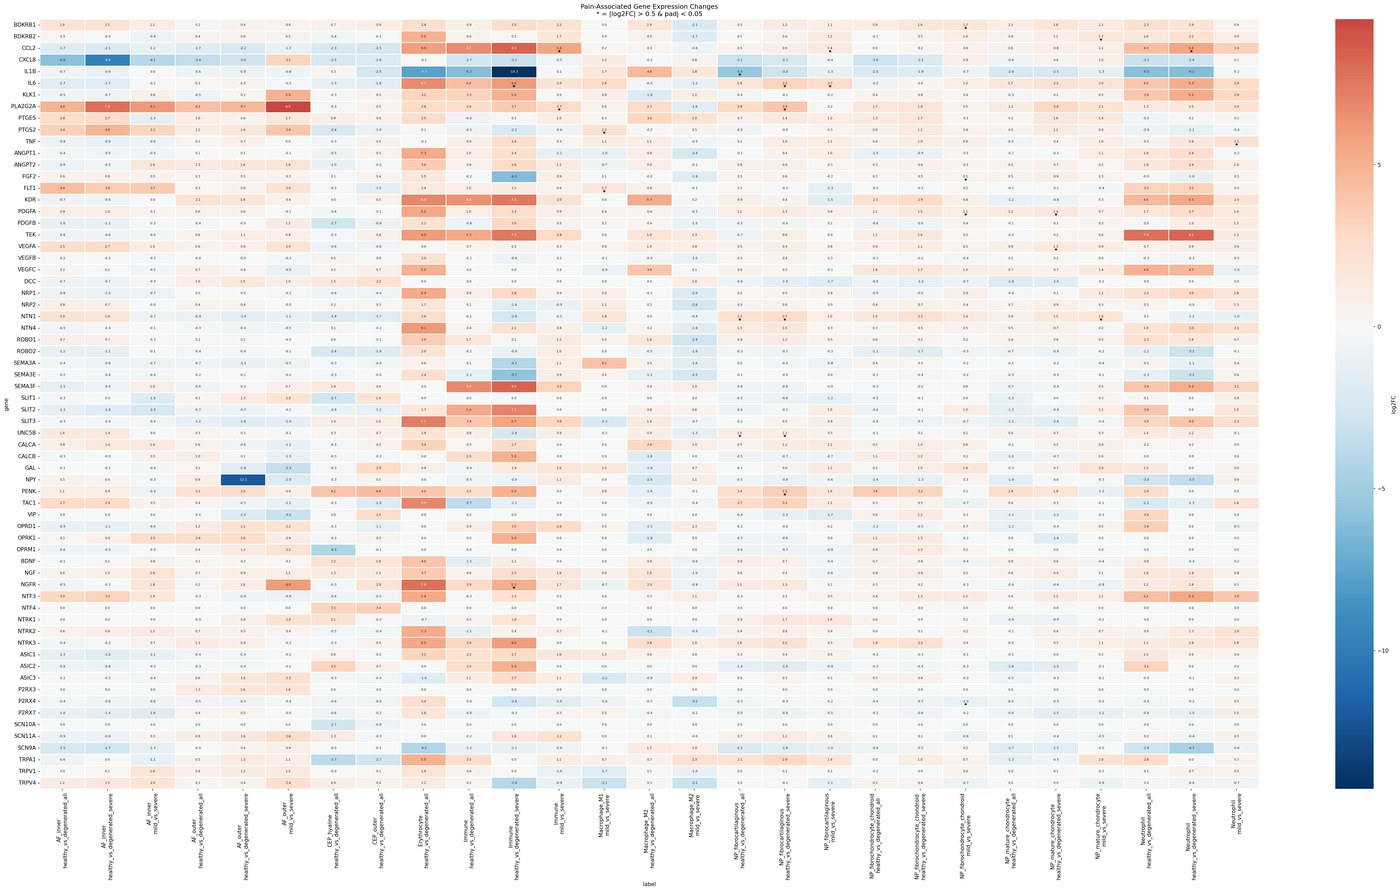

In [15]:
pain_heatmap = TV4 / 'pain_genes_heatmap.png'
if pain_heatmap.exists():
    _show_compressed(pain_heatmap, max_width=1400)
else:
    print('Pain heatmap not found')